# immgenT-CD8 dataset — analysis notebook


This notebook documents data processing, annotation, and figure generation for the immgenT-CD8 T-cell CITE-seq atlas.

**CITE-seq** (cellular indexing of transcriptomes and epitopes by sequencing) jointly profiles transcriptome-wide gene expression and surface protein (ADT) abundance in single cells ([Stoeckius et al., 2017](https://www.nature.com/articles/nmeth.4380)).

**Dataset:** immgenT-CD8 T cells (multi-organ, multi-condition CITE-seq).

**Notebook structure (paper figure numbering):**
- **Figure 1** — immgenT resolves CD8+ T cell heterogeneity into 21 discrete clusters and a reference
embedding.
- **Figure 2** — Shared CD8+ T cell states across immune conditions.
- **Figure 3** — Effector CD8+ T cells comprise three distinct recurrent states.
- **Figure 4** — Circulating memory CD8+ T cells map to three main clusters that are present broadly beyond
acute infections.
- **Figure 5** — Tissue-resident memory CD8+ T cells converge on a single dominant transcriptional state while
maintaining tissue-specific differences.
- **Figure 6** — Exhaustion and residency-associated states form a continuum.
- **Extended Data Figure 1** — Comprehensive integration of the CD8αβ immgenT framework.
- **Extended Data Figure 2** — Acute effector states (clusters CD8.I, .J, and .K).
- **Extended Data Figure 3** — Phenotypic and transcriptional signatures of circulating memory states
(clusters CD8.E, .F, .G, and .H).
- **Extended Data Figure 4** — Surface-marker and transcriptional heterogeneity of tissue-resident memory
CD8+ T cells in cluster CD8.Q.
- **Extended Data Figure 5** — Detailed mapping of the exhaustion/residency continuum and
progenitor-exhausted cells.
- **Extended Data Figure 7** — immgenT-CD8 flow cytometry panel and validation.
- **Extended Data Table 2** — Summary of endogenous and antigen-specific cell counts across samples, conditions and tissues (only samples with at least 10 total CD8+ T cells recovered in at least one cluster are shown).

For figures and tables not covered by this notebook, including T-RBI analyses, refer to immgenT-Cosmology (Magill et al., bioRxiv 2026).

Paths and intermediate filenames reflect the analysis environment used to generate the paper figures; adjust them as needed when re-running.

# How to use this object

This MuData contains the curated immgenT-CD8 CITE-seq dataset with sparse raw counts, full metadata, and the main embedding (MDE_INCREMENTAL).

After loading the object, a typical workflow is:

- Start from the raw counts (layers["counts"] or .X)
- Normalize, log-transform and scale the modalities (sc.pp.normalize_total → sc.pp.log1p → sc.pp.scale)
- Optionally apply CLR normalization to the ADT modality (muon.prot.pp.clr)
- Use the pre-computed embedding available in obsm["MDE_INCREMENTAL"] for visualization and downstream analysis

All key metadata columns are already present in both modalities.
- Ag_spe_v1: prioritize CITE-Seq congenic markers for annotation of P14 CD8+ T cells
- Ag_spe_v2: prioritize TCR-Seq for annotation of P14 CD8+ T cells

# Libraries and environment


Import required libraries and configure plotting defaults.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import gseapy as gp
import matplotlib.pyplot as plt
import scanpy as sc
import muon as mu
from muon import prot as pt
import random

random.seed(0)
np.random.seed(0)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sc.set_figure_params(frameon=True, figsize=(4, 4), dpi_save=300, transparent=True, format='eps',)
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'


Create color dictionary.


In [76]:

custom_colors = {
    'CD8.A': '#00008B',      # blue2 (darkblue)
    'CD8.B': '#FF7F00',      # darkorange2
    'CD8.C': '#EE0000',      # red2
    'CD8.D': '#556B2F',      # darkolivegreen
    'CD8.E': '#6B8E23',      # darkolivegreen2 (olive drab)
    'CD8.F': '#9400D3',      # darkorchid2
    'CD8.G': '#CD3333',      # brown2
    'CD8.H': '#7AC5CD',      # cadetblue2
    'CD8.I': '#9BCD9B',      # darkseagreen2
    'CD8.J': '#D02090',      # violetred2
    'CD8.K': '#9932CC',      # darkorchid
    'CD8.P': '#000000',      # black
    'CD8.Q': '#76EE00',      # chartreuse2
    'CD8.R': '#FF69B4',      # pink2 (hotpink)
    'CD8.S': '#CD950C',      # darkgoldenrod2
    'CD8.T': '#FF8C00',      # darkorange
    'CD8.wM': '#808080',     # grey
    'CD8.wU': '#00EEEE',     # cyan2
    'CD8.wV': '#0000FF',     # blue
    'CD8.wX': '#EEC591',     # burlywood2
    'CD8.wY': '#00B7EB'      # deepskyblue2
}

Setup object.

In [3]:
# ------------------------------------------------------------
# Load the public object
# ------------------------------------------------------------
mdata = mu.read_h5mu("data/immgenT-CD8.h5mu")  # ← update path if needed
rna = mdata["RNA"]
adt = mdata["ADT"]
print(mdata)

# ------------------------------------------------------------
# Standard normalization + scaling (RNA)
# ------------------------------------------------------------
# Keep raw counts in a layer
rna.layers["counts"] = rna.X.copy()

# Normalize → log1p
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
rna.layers["log_norm"] = rna.X.copy()

# Scale
sc.pp.scale(rna, max_value=10)
rna.layers["scaled"] = rna.X.copy()

# ------------------------------------------------------------
# Standard normalization + scaling (ADT)
# ------------------------------------------------------------
adt.layers["counts"] = adt.X.copy()

# Option A: total-count normalization + log1p
sc.pp.normalize_total(adt, target_sum=1e4)
sc.pp.log1p(adt)
adt.layers["log_norm"] = adt.X.copy()

# Reset again to raw counts
adt.X = adt.layers["counts"].copy()

# Option B: Centered Log-Ratio (CLR) – often better for protein data
from muon import prot as pt
pt.pp.clr(adt)
adt.layers["clr"] = adt.X.copy()

# Scale (applied on the current .X, which is CLR at this point)
sc.pp.scale(adt, max_value=10)
adt.layers["scaled"] = adt.X.copy()

print("\nPreprocessing done.")
print(mdata)

MuData object with n_obs × n_vars = 206160 × 55674
  2 modalities
    RNA:	206160 x 55494
      obs:	'Ag_spe_v1', 'Ag_spe_v2', 'G2M.Score', 'HT', 'IGT', 'IGTHT', 'IGT_cellID', 'MAIT', 'S.Score', 'age_weeks', 'cite_seq', 'cluster_annotation', 'comments', 'condition_broad', 'condition_detailed', 'condition_detailed_organ', 'condition_detailed_simplified', 'exp_id', 'exp_name', 'exp_number', 'gating_strategy', 'genetics', 'ht_number', 'iNKT', 'ident', 'igt_number', 'infection_agent', 'infection_dose', 'infection_mode', 'jax', 'lab', 'nCount_ADT', 'nCount_RNA', 'nFeature_ADT', 'nFeature_RNA', 'organ', 'organ_simplified', 'organ_uberon_id', 'organism_name', 'pool_of_mice', 'prep_description', 'sample_code', 'sample_name', 'sample_type', 'sex', 'strain', 'target_cells', 'target_cells_simplified', 'timepoint', 'transgenic_byTCR', 'transgenic_tet_byCITEseq', 'transgenic_tet_bySorting', 'treat_agent', 'treat_dose', 'tumor'
      uns:	'X_name'
      obsm:	'MDE_INCREMENTAL'
      layers:	'counts'

# Fig. 4


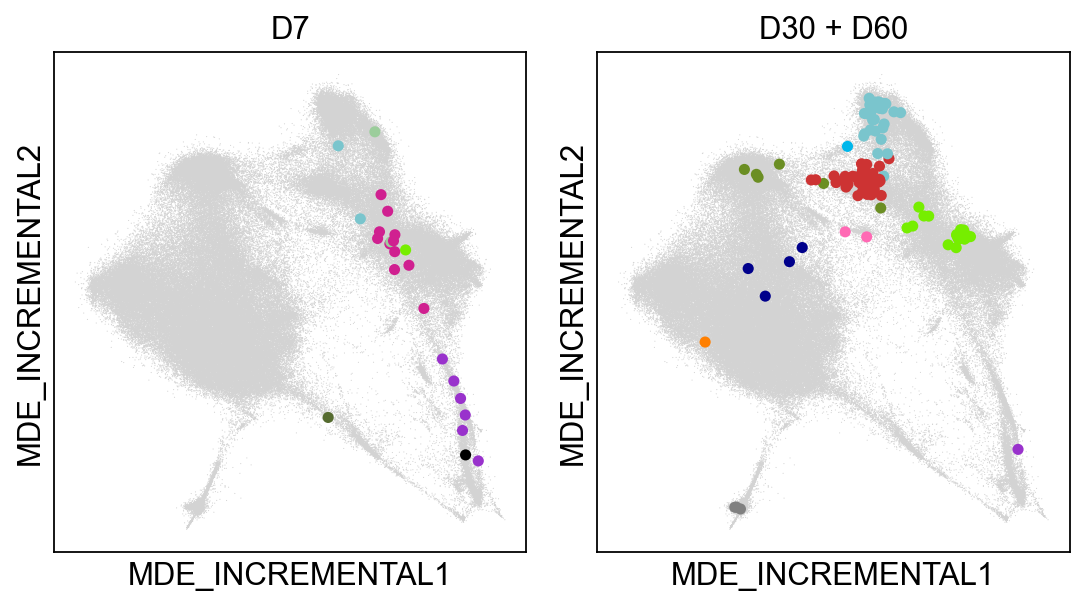

Combined plot saved: Fig_4a.pdf


In [25]:
# Fig. 4a — Circulating memory clusters on MDE plot
# Memory clusters: early (D7) vs late (D30+D60) SLO embeddings
titles = ['D7', 'D30 + D60']

# Define the three organs to merge
organs = ['LNmediastinal', 'spleen', 'LNmesenteric']

# Gray background for non-highlighted cells
default_color = '#BAB0AC' # Gray for cells not meeting the condition

# Set up the figure with TWO subplots
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# Iterate over the two plots
for idx, (title, ax) in enumerate(zip(titles, axes)):
    
    if idx == 0:  # First plot: D7 only
        conditions = [f"{organ}_LCMVarm_D7" for organ in organs]
    else:         # Second plot: D30 + D60
        conditions = [f"{organ}_LCMVarm_D30" for organ in organs] + \
                     [f"{organ}_LCMVarm_D60" for organ in organs]
    
    # Create mask for the selected conditions
    mask = rna.obs['condition_detailed_organ'].isin(conditions)
    
    # Create a new column for coloring based on conditions
    rna.obs['highlight_color'] = np.where(
        mask & (rna.obs['Ag_spe_v2'].str.lower() == 'p14'),
        rna.obs['cluster_annotation'], # Use cluster_annotation for highlighted cells
        None # None for cells that don't meet the condition
    )
    
    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 100, 1)
    
    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None, # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=title # Use nice title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Fig_4a.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Fig_4a.pdf")


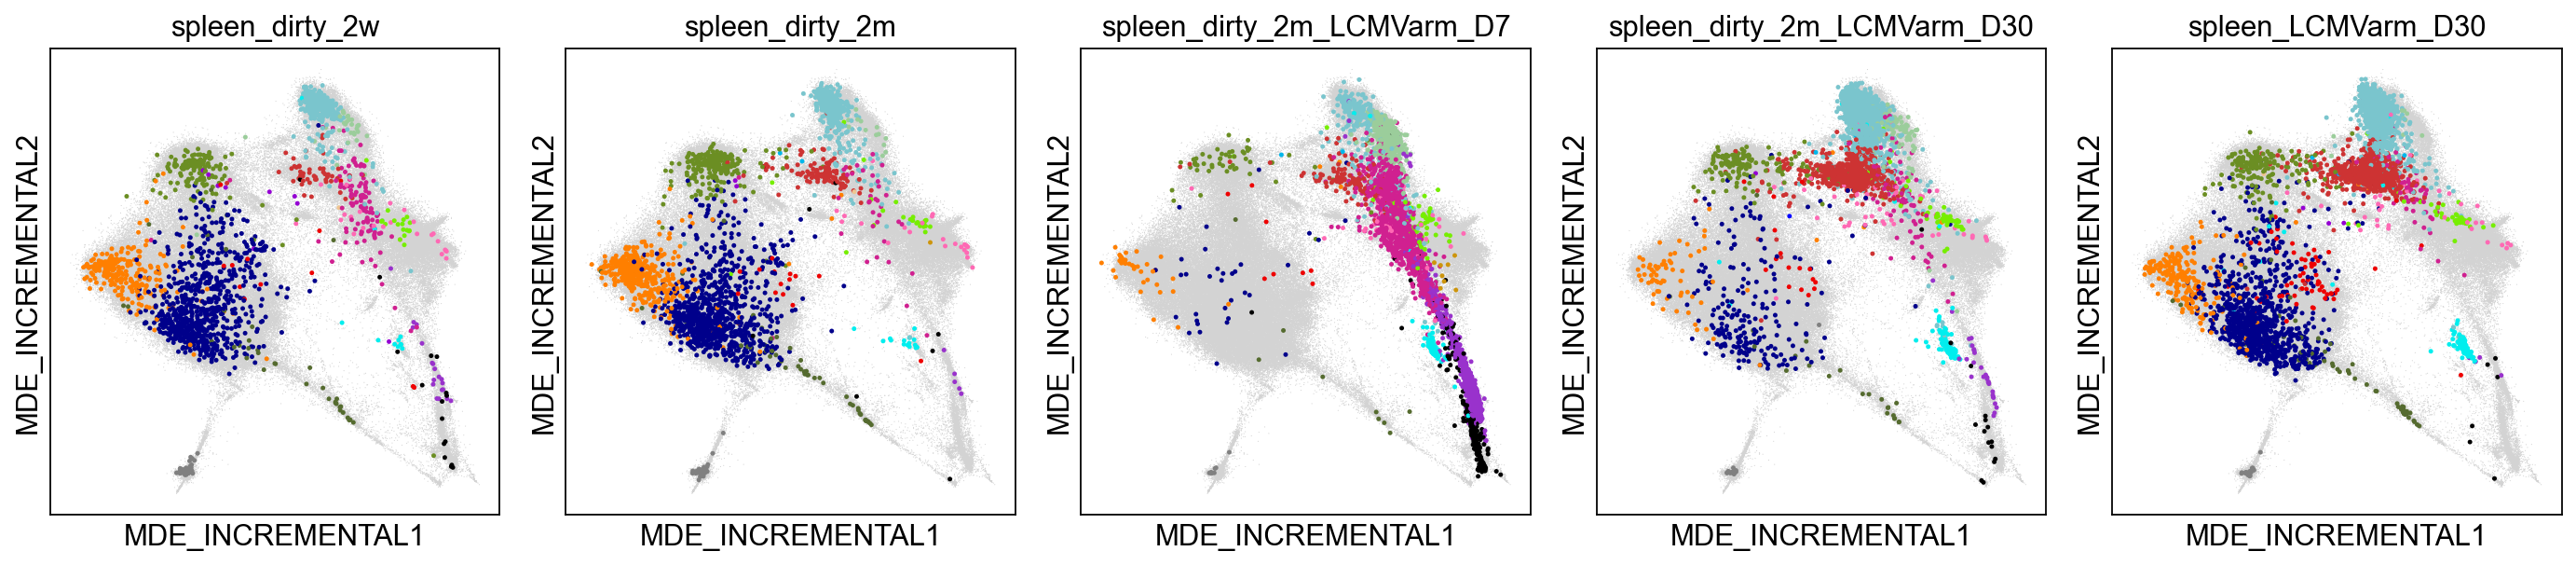

Combined plot saved: Fig_4a_v2.pdf


In [26]:
# Fig. 4a — spleen LCMV tetramer⁺ populations on MDE
# Conditions to highlight
conditions = ['spleen_dirty_2w', 'spleen_dirty_2m',
'spleen_dirty_2m_LCMVarm_D7', 'spleen_dirty_2m_LCMVarm_D30',
'spleen_LCMVarm_D30']
# Gray background for non-highlighted cells
default_color = '#BAB0AC' # Gray for cells not meeting the condition
# Multi-panel layout
fig, axes = plt.subplots(1, len(conditions), figsize=(3.5 * len(conditions), 4)) # 3 subplots horizontally, adjusted size
# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
# Create a new column for coloring based on conditions
    if condition in ['spleen_dirty_2w', 'spleen_dirty_2m']:
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'] == condition) & (rna.obs['Ag_spe_v1'].str.lower() == 'endogenous'),
            rna.obs['cluster_annotation'], # Use cluster_annotation for highlighted cells
None # None for cells that don't meet the condition
        )
    else:
        rna.obs['highlight_color'] = np.where(
            (rna.obs['condition_detailed_organ'] == condition) & (rna.obs['Ag_spe_v1'].str.lower() == 'gp33gp276np396tetp'),
            rna.obs['cluster_annotation'], # Use cluster_annotation for highlighted cells
None # None for cells that don't meet the condition
        )
# Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)
# Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None, # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=condition # Add condition as subplot title
    )
# Adjust layout to prevent overlap
plt.tight_layout()
# Save and show the combined plot
plt.savefig("Fig_4a_v2.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Fig_4a_v2.pdf")


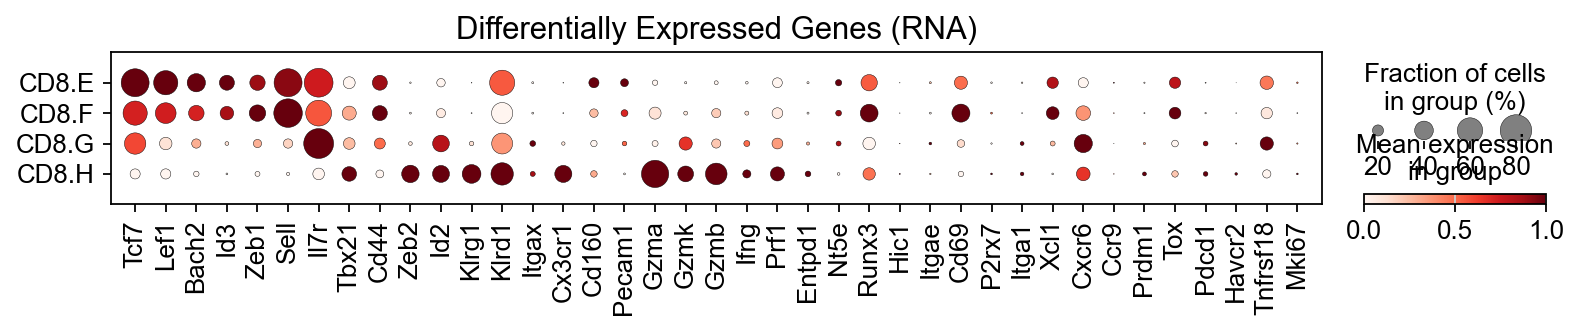

Plot saved: Fig_4d.pdf


In [27]:
# Fig. 4d — Dot plot of DEGs in memory clusters
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc  # Explicitly import scanpy for clarity

# Define selected genes
selected_genes = ["Tcf7", "Lef1", "Bach2", "Id3", "Zeb1", "Sell", "Il7r", "Tbx21", "Cd44", "Zeb2",
                  "Id2", "Klrg1", "Klrd1", "Itgax", "Cx3cr1", "Cd160", "Pecam1", "Gzma", "Gzmk",
                  "Gzmb", "Ifng", "Prf1", "Entpd1", "Nt5e", "Runx3", "Hic1", "Itgae", "Cd69",
                  "P2rx7", "Itga1", "Xcl1", "Cxcr6", "Ccr9", "Prdm1", "Tox", "Pdcd1", "Havcr2",
                  "Tnfrsf18", "Mki67"]

# Subset mdata['RNA'] to include only clusters CD8.E, CD8.F, CD8.G, and CD8.H
subset_adata = mdata['RNA'][mdata['RNA'].obs['cluster_annotation'].isin(['CD8.E', 'CD8.F', 'CD8.G', 'CD8.H']), :]

# Create dot plot with the subsetted data
sc.pl.dotplot(subset_adata, var_names=list(selected_genes), groupby='cluster_annotation',
              use_raw=False,  # Set to True if .X is raw and you have .raw
              cmap='Reds',    # Color map for expression
              title='Differentially Expressed Genes (RNA)',
              standard_scale='var',  # Scale by variable (gene)
              figsize=(11.5, 1.25),      # Try passing figsize directly
              show=False)
plt.savefig('Fig_4d.pdf', format='pdf', bbox_inches='tight')
plt.show()
plt.close()
print('Plot saved: Fig_4d.pdf')


Loaded Excel file with 688 rows and 94 columns.
After target_cells filters: 634 rows remain.
After excluding KbDb conditions: 622 rows remain.
After excluding baseline: 365 rows remain.
After aggregating replicates: 181 unique conditions.
After ≥ 10 cells (averaged) in at least one cluster: 111 conditions remain.
Selected top 50 unique conditions by average combined proportion.


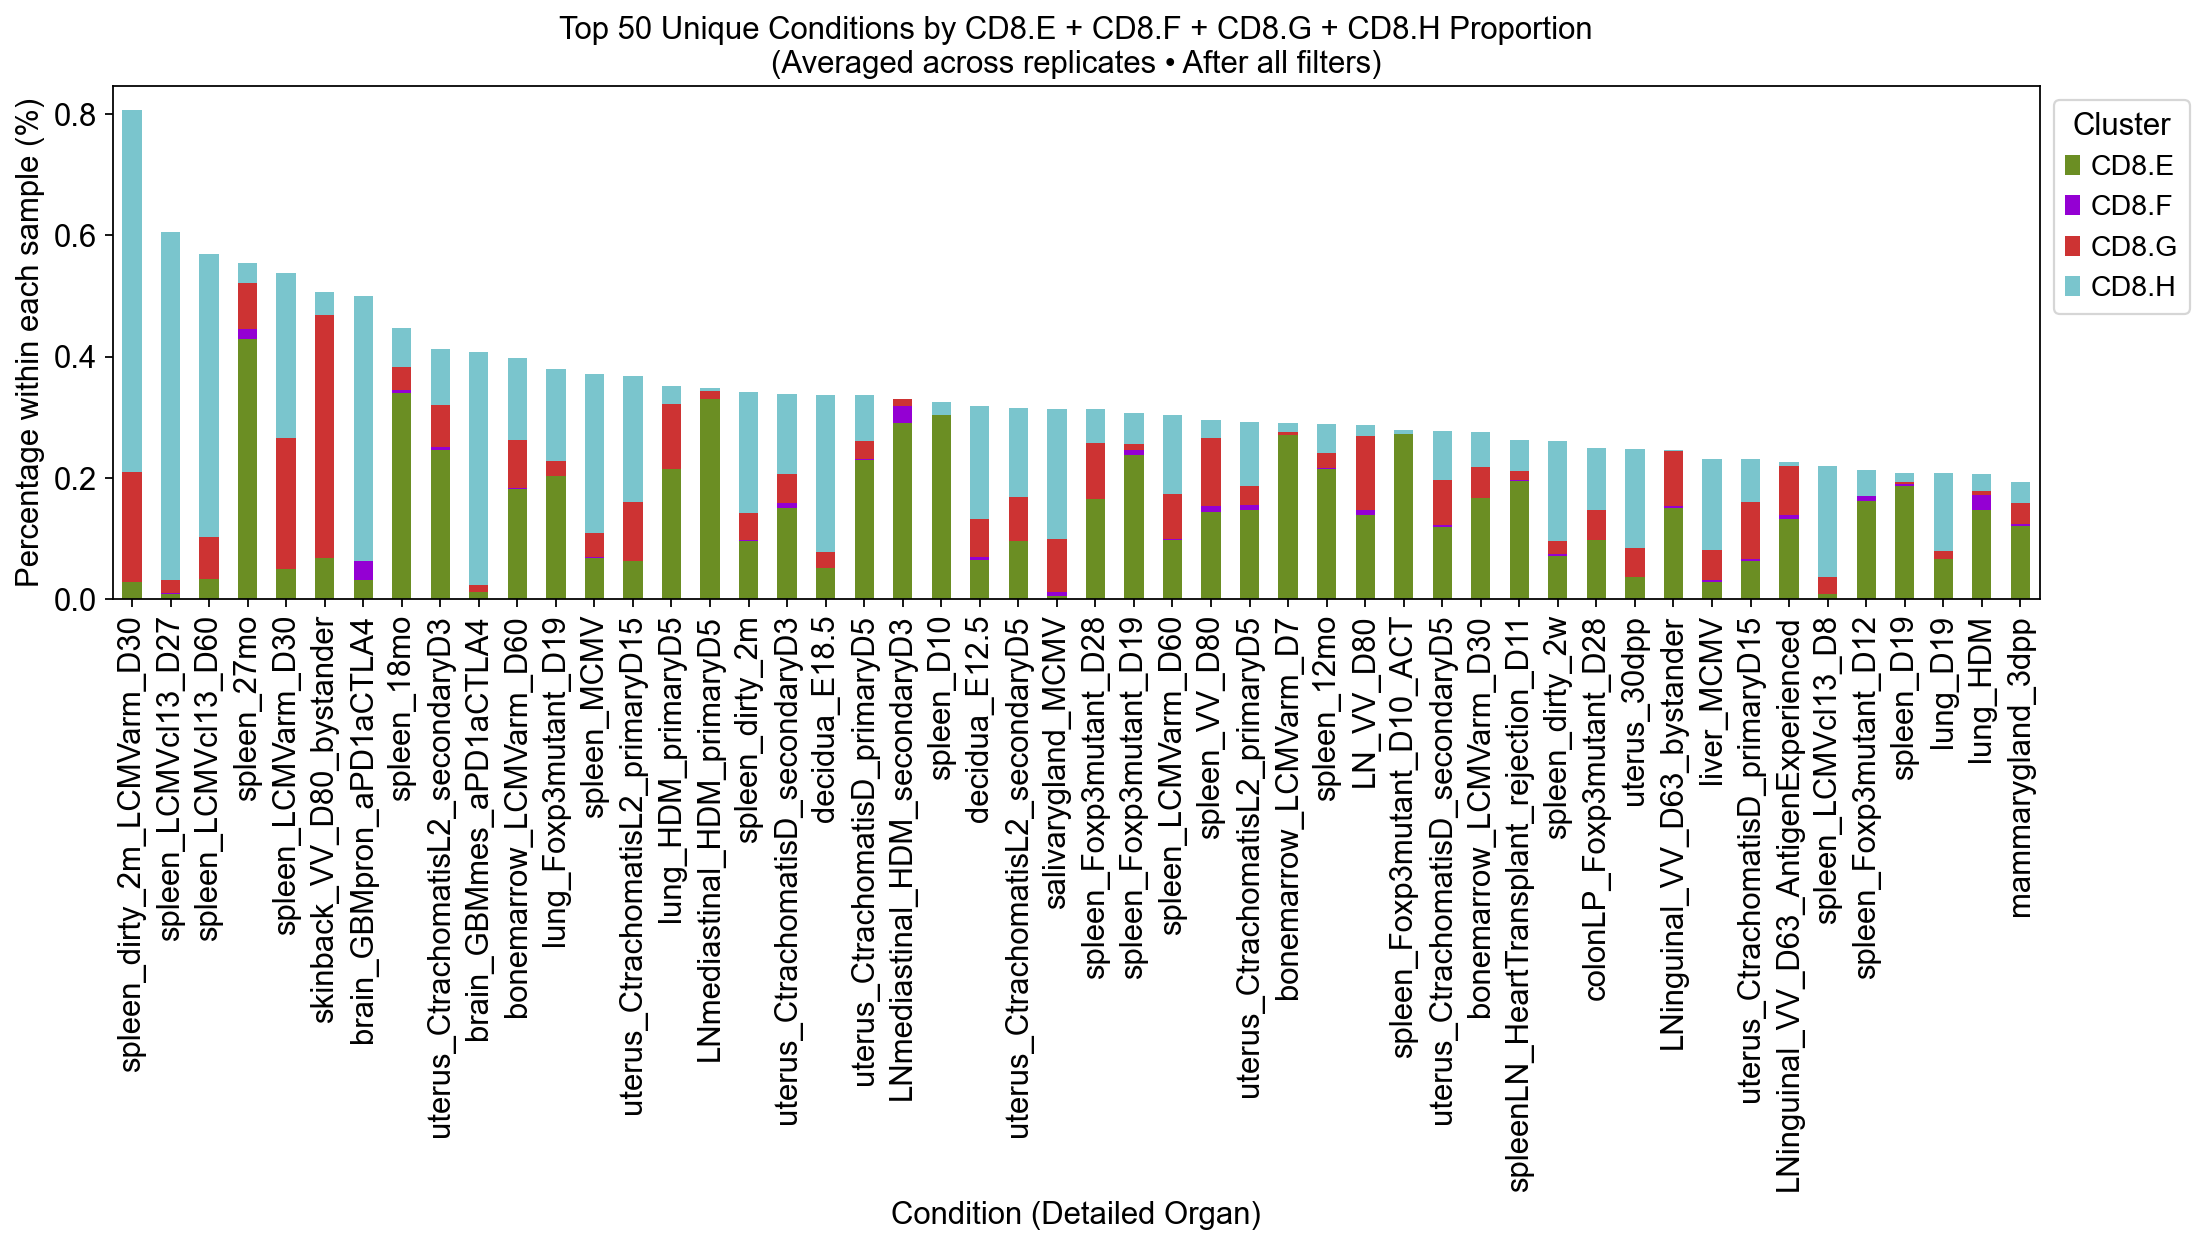

Stacked bar plot saved: Fig_4e.pdf

Top 10 unique conditions:
              condition_detailed_organ  total_prop  CD8.E.ncells  \
161        spleen_dirty_2m_LCMVarm_D30    0.806153     52.666667   
154                spleen_LCMVcl13_D27    0.606045      4.666667   
155                spleen_LCMVcl13_D60    0.569212      9.000000   
131                        spleen_27mo    0.554656    106.000000   
149                 spleen_LCMVarm_D30    0.537820     59.750000   
103          skinback_VV_D80_bystander    0.506053    156.333333   
34            brain_GBMpron_aPD1aCTLA4    0.500000      1.000000   
130                        spleen_18mo    0.447158    259.500000   
179  uterus_CtrachomatisL2_secondaryD3    0.412063     51.500000   
32             brain_GBMmes_aPD1aCTLA4    0.406977      1.000000   

     CD8.F.ncells  CD8.G.ncells  CD8.H.ncells  CD8.E.prop  CD8.F.prop  \
161      0.333333    327.666667   1098.666667    0.028910    0.000192   
154      0.333333     11.333333    300.0000

In [28]:
# Fig. 4e — Stacked bar plot of memory cluster frequencies
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file
file_path = 'data/immgenT-CD8.xlsx'
df = pd.read_excel(file_path)

print(f"Loaded Excel file with {df.shape[0]} rows and {df.shape[1]} columns.")

# Define columns
prop_cols = ['CD8.E.prop', 'CD8.F.prop', 'CD8.G.prop', 'CD8.H.prop']
ncells_cols = ['CD8.E.ncells', 'CD8.F.ncells', 'CD8.G.ncells', 'CD8.H.ncells']

# === FILTERS (applied on original rows before averaging) ===
if 'target_cells' in df.columns:
    df = df[~df['target_cells'].str.contains('CD4\+ CD44\+', case=False, na=False)].copy()
    unwanted = ['Treg', 'CD4+ T', 'DN', 'DO11.10 KJ1-26', 'OT2', 'TCRBV-TCRGD', 'TFH',
                'Vd6b F4.22', 'Vg4 49.2', 'Vg6 1C10', 'Vg7 F2.67', 'thymocytes']
    mask = df['target_cells'].isin(unwanted) | df['target_cells'].str.contains('|'.join(unwanted), case=False, na=False)
    df = df[~mask].copy()
    print(f"After target_cells filters: {df.shape[0]} rows remain.")

# Exclude KO conditions
exclude_conditions = ['KbDbKO', 'KbDbQa1KO', 'KbDbQa1KO_MCMV']
exclude_mask = df['condition_detailed_organ'].str.contains('|'.join(exclude_conditions), case=False, na=False)
df = df[~exclude_mask].copy()
print(f"After excluding KbDb conditions: {df.shape[0]} rows remain.")

# Exclude baseline
if 'condition_detailed_simplified' in df.columns:
    df = df[df['condition_detailed_simplified'] != 'baseline'].copy()
    print(f"After excluding baseline: {df.shape[0]} rows remain.")

# === AGGREGATE REPLICATES (Group by condition_detailed_organ) ===
group_cols = ['condition_detailed_organ']

agg_dict = {col: 'mean' for col in prop_cols + ncells_cols}
if 'target_cells' in df.columns:
    agg_dict['target_cells'] = 'first'   # keep one value for reference

df_agg = df.groupby(group_cols, as_index=False).agg(agg_dict)

print(f"After aggregating replicates: {df_agg.shape[0]} unique conditions.")

# === FILTER on averaged ncells: ≥10 in at least one cluster ===
min_cells = 10
valid_mask = (df_agg['CD8.E.ncells'] >= min_cells) | \
             (df_agg['CD8.F.ncells'] >= min_cells) | \
             (df_agg['CD8.G.ncells'] >= min_cells) | \
             (df_agg['CD8.H.ncells'] >= min_cells)

df_filtered = df_agg[valid_mask].copy()
print(f"After ≥ {min_cells} cells (averaged) in at least one cluster: {df_filtered.shape[0]} conditions remain.")

# Calculate total proportion for ranking
df_filtered['total_prop'] = df_filtered[prop_cols].sum(axis=1)
df_filtered = df_filtered[df_filtered['total_prop'] > 0].copy()

# Select top 50 unique conditions
df_top50 = df_filtered.nlargest(50, 'total_prop')

print(f"Selected top 50 unique conditions by average combined proportion.")

# Prepare for plotting
freq_table = df_top50[prop_cols].copy()
freq_table.index = df_top50['condition_detailed_organ']
freq_table.columns = ['CD8.E', 'CD8.F', 'CD8.G', 'CD8.H']

# Plot using your pre-existing custom_colors
fig, ax = plt.subplots(figsize=(14, 8))
freq_table.plot(kind='bar', stacked=True, ax=ax, 
                color=[custom_colors[col] for col in freq_table.columns])

ax.set_xlabel('Condition (Detailed Organ)')
ax.set_ylabel('Percentage within each sample (%)')
ax.set_title('Top 50 Unique Conditions by CD8.E + CD8.F + CD8.G + CD8.H Proportion\n(Averaged across replicates • After all filters)')
ax.grid(False)
ax.legend(title='Cluster', bbox_to_anchor=(1, 1), loc='upper left')

plt.xticks(rotation=90, ha='center')
plt.tight_layout()

# Save
plt.savefig('Fig_4e.pdf', bbox_inches='tight')
plt.show()
plt.close()

print("Stacked bar plot saved: Fig_4e.pdf")

# Preview
print("\nTop 10 unique conditions:")
print(df_top50[['condition_detailed_organ', 'total_prop'] + ncells_cols + prop_cols].head(10))


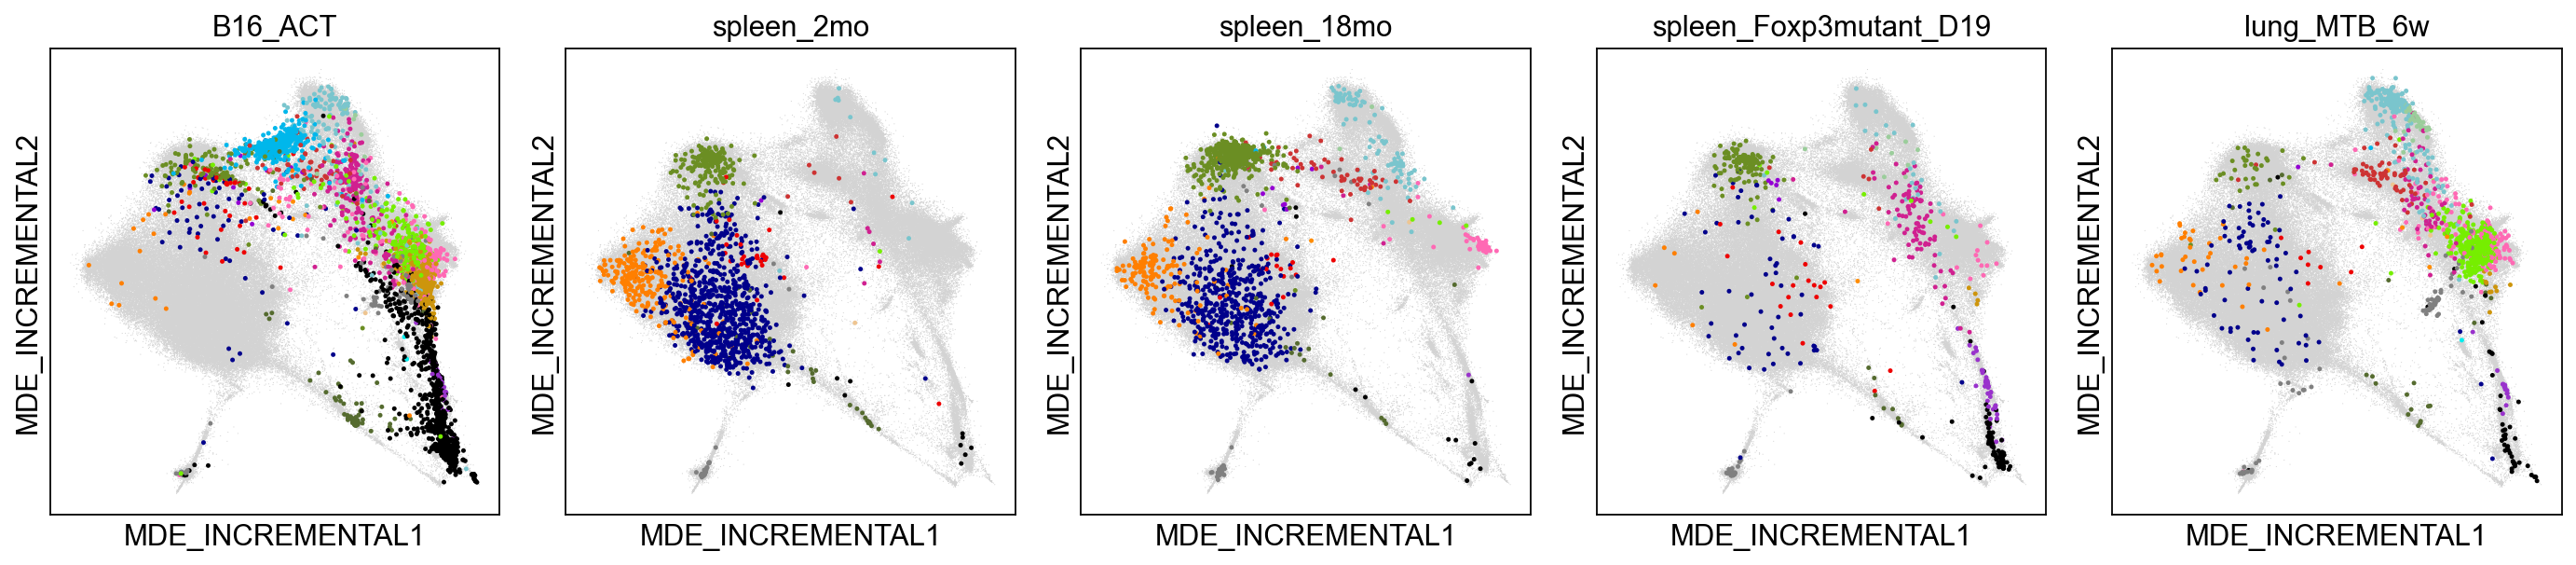

Combined plot saved: Fig_4f.pdf


In [29]:
# Fig. 4f — Representative conditions enriched for memory clusters
conditions = ['B16_ACT','spleen_2mo', 'spleen_18mo', 'spleen_Foxp3mutant_D19', 'lung_MTB_6w']

# Gray background for non-highlighted cells
default_color = '#BAB0AC'  # Gray for cells not meeting the condition

# Multi-panel layout
fig, axes = plt.subplots(1, 5, figsize=(17.5, 4))  # 4 subplots horizontally, adjusted size

# Iterate over conditions and corresponding axes
for idx, (condition, ax) in enumerate(zip(conditions, axes)):
    # Create a new column for coloring based on conditions
    rna.obs['highlight_color'] = np.where(
        rna.obs['condition_detailed_organ'] == condition,
        rna.obs['cluster_annotation'],  # Use cluster_annotation for highlighted cells
        None  # None for cells that don't meet the condition
    )
    
    # Set dot sizes: larger for highlighted cells
    sizes = np.where(rna.obs['highlight_color'].notnull(), 20, 1)
    
    # Plot MDE
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        legend_loc=None,  # No legend
        ax=ax,
        size=sizes,
        show=False,
        title=condition  # Add condition as subplot title
    )

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the combined plot
plt.savefig("Fig_4f.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Combined plot saved: Fig_4f.pdf")


# Fig. 5


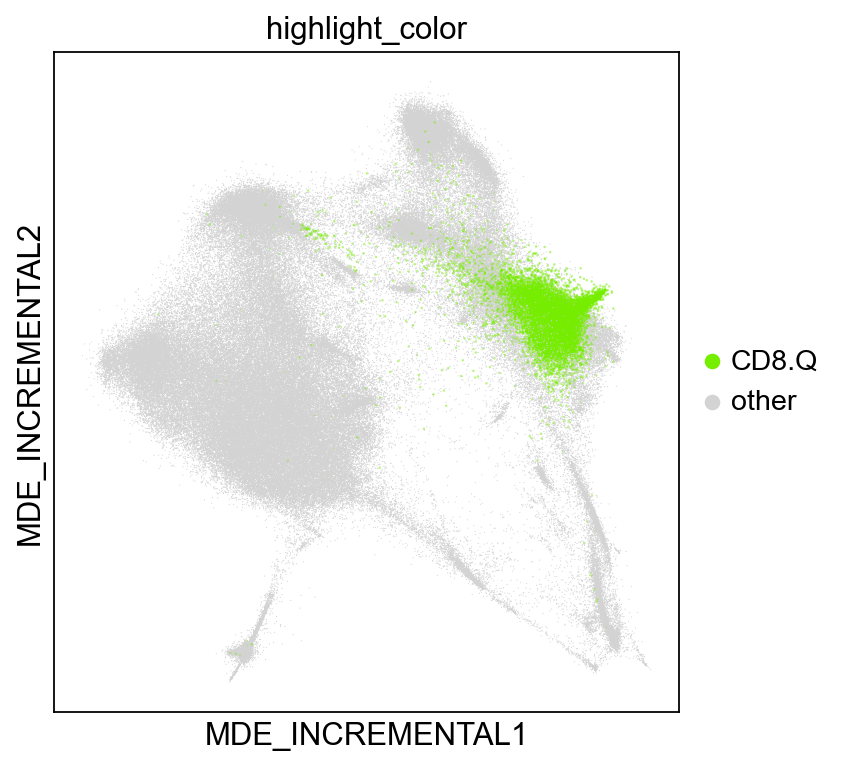

Plot saved: Fig_5a.pdf


In [31]:
# Fig. 5a — MDE plot with CD8.Q highlighted
# Gray background for non-highlighted cells
default_color = '#d3d3d3'  # Gray for cells not meeting the condition

# Create a new column for coloring based on conditions
rna.obs['highlight_color'] = np.where(
    rna.obs['cluster_annotation'] == 'CD8.Q',
    'CD8.Q',  # Use category name for highlighted cells
    'other'  # Use category name for non-highlighted cells
)

# Define palette for the categories in highlight_color
palette = {
    'CD8.Q': custom_colors.get('CD8.Q'),  # Use color from custom_colors or default to red
    'other': default_color  # Gray for non-highlighted cells
}

# Set up the plot
plt.figure(figsize=(5.5, 5))  # Single plot, moderate size
ax = plt.gca()

# Set dot parameters: larger for highlighted cells
sizes = np.where(rna.obs['highlight_color'] == 'CD8.Q', 5, 1)  # Optional: larger size for highlighted cells
alphas = np.where(rna.obs['highlight_color'] == 'CD8.Q', 0.5, 1)  # Optional: set opacity for highlighted cells

# Plot MDE
sc.pl.embedding(
    rna,
    basis="MDE_INCREMENTAL",
    color="highlight_color",
    palette=palette,  # Use the defined palette
    legend_loc="right margin",
    ax=ax,
    alpha=alphas,
    size=sizes,
    show=False,
)

# Save and show the plot
plt.tight_layout()
plt.savefig("Fig_5a.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Fig_5a.pdf")


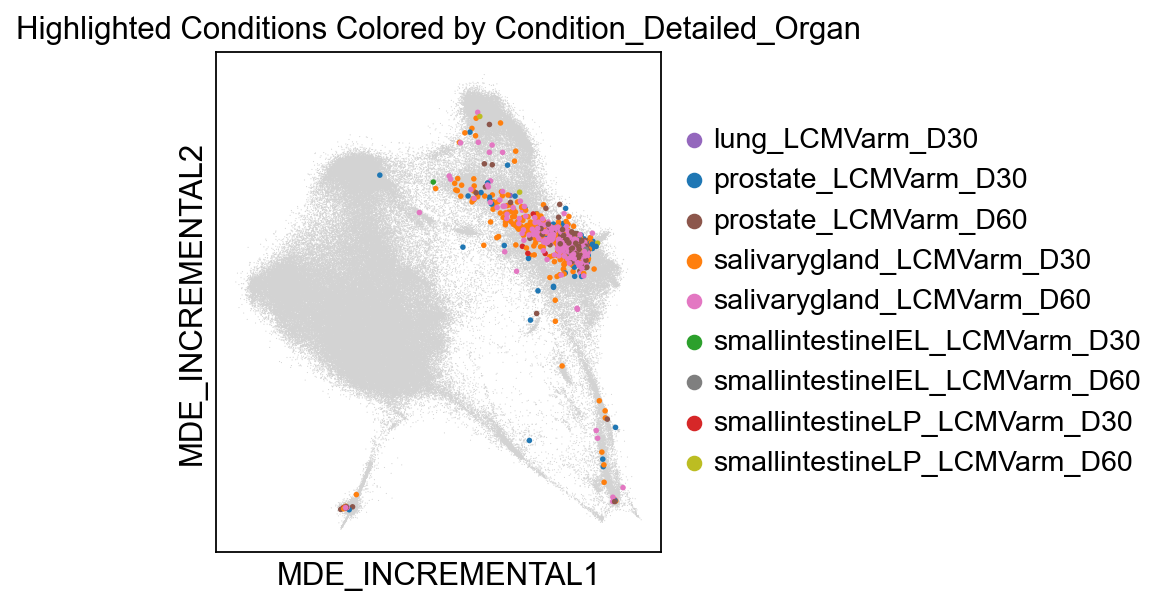

Plot saved: Fig_5b.pdf


In [32]:
# Fig. 5b — MDE plot with LCMVarm memory cells from non-lymphoid tissues highlighted
# List of condition_detailed_organ to check
conditions = [
    'prostate_LCMVarm_D30', 'salivarygland_LCMVarm_D30', 'smallintestineIEL_LCMVarm_D30',
    'smallintestineLP_LCMVarm_D30', 'lung_LCMVarm_D30', 'prostate_LCMVarm_D60',
    'salivarygland_LCMVarm_D60', 'smallintestineIEL_LCMVarm_D60', 'smallintestineLP_LCMVarm_D60',
    'lung_LCMVarm_D60'
]

# Define custom palette for conditions
custom_colors = {
    'prostate_LCMVarm_D30': '#1f77b4',  # Blue
    'salivarygland_LCMVarm_D30': '#ff7f0e',  # Orange
    'smallintestineIEL_LCMVarm_D30': '#2ca02c',  # Green
    'smallintestineLP_LCMVarm_D30': '#d62728',  # Red
    'lung_LCMVarm_D30': '#9467bd',  # Purple
    'prostate_LCMVarm_D60': '#8c564b',  # Brown
    'salivarygland_LCMVarm_D60': '#e377c2',  # Pink
    'smallintestineIEL_LCMVarm_D60': '#7f7f7f',  # Gray
    'smallintestineLP_LCMVarm_D60': '#bcbd22',  # Olive
    'lung_LCMVarm_D60': '#17becf'  # Cyan
}

# Filter for specified conditions
subset_conditions = rna[
    (rna.obs['condition_detailed_organ'].isin(conditions)) & 
    (rna.obs['Ag_spe_v2'] == 'P14')
].copy()

# Create figure and axis
fig, ax = plt.subplots(figsize=(6.5, 4))

# Plot all cells in gray as background
sc.pl.embedding(
    rna,
    basis='MDE_INCREMENTAL',
    color='condition_detailed_organ',
    palette=['#d3d3d3'],  # Gray color for all cells
    size=1,  # Smaller point size for background
    show=False,
    ax=ax,
    legend_loc=None  # Remove legend
)

# Overlay cells from specified conditions, colored by condition_detailed_organ
sc.pl.embedding(
    subset_conditions,
    basis='MDE_INCREMENTAL',
    color='condition_detailed_organ',
    groups=conditions,  # Ensure only specified conditions are colored
    palette=custom_colors,  # Apply custom palette
    title='Highlighted Conditions Colored by Condition_Detailed_Organ',
    legend_loc='right margin',
    size=25,  # Larger point size for foreground
    show=False,
    ax=ax
)

# Save and show the plot
plt.tight_layout()
plt.savefig("Fig_5b.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Fig_5b.pdf")


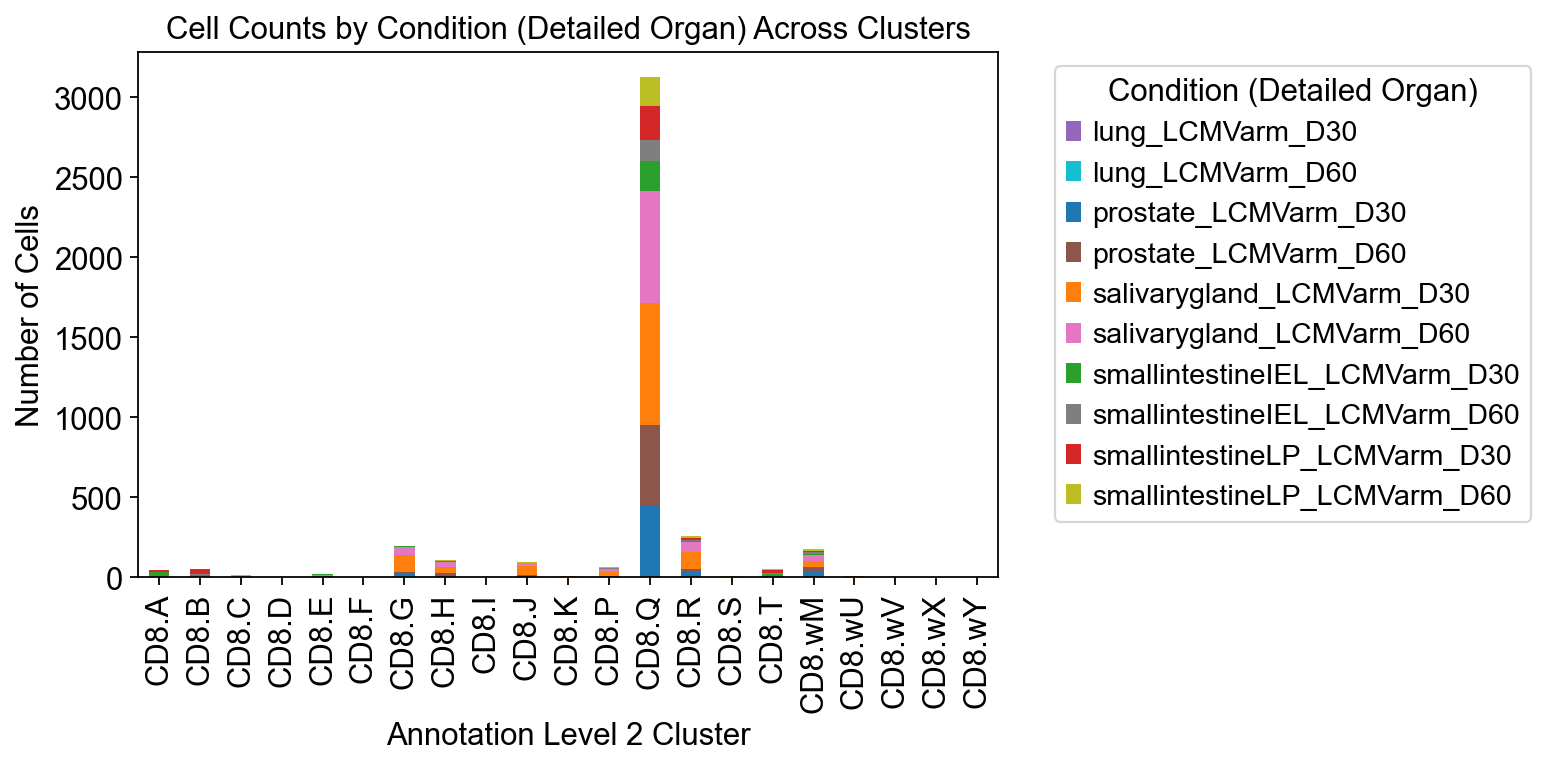

Plot saved: Fig_5c.pdf


In [33]:
# Fig. 5c — Stacked bar plot of cell counts by condition
# List of condition_detailed_organ to check
conditions = [
'prostate_LCMVarm_D30', 'salivarygland_LCMVarm_D30', 'smallintestineIEL_LCMVarm_D30',
'smallintestineLP_LCMVarm_D30', 'lung_LCMVarm_D30', 'prostate_LCMVarm_D60',
'salivarygland_LCMVarm_D60', 'smallintestineIEL_LCMVarm_D60', 'smallintestineLP_LCMVarm_D60',
'lung_LCMVarm_D60'
]

# Filter for specified conditions
subset_conditions = rna[
    (rna.obs['condition_detailed_organ'].isin(conditions))
].copy()

# Get the FULL list of cluster_annotation that exist in your dataset (not just the filtered subset)
all_annotations = rna.obs['cluster_annotation'].cat.categories.tolist()

# Calculate cell counts and reindex to force ALL cluster_annotation (with 0s where missing)
counts = (subset_conditions.obs
          .groupby(['cluster_annotation', 'condition_detailed_organ'])
          .size()
          .unstack(fill_value=0)
          .reindex(index=all_annotations, fill_value=0))   # <-- this line forces all levels

# Define custom colors for conditions
custom_colors = {
'prostate_LCMVarm_D30': '#1f77b4',
'salivarygland_LCMVarm_D30': '#ff7f0e',
'smallintestineIEL_LCMVarm_D30': '#2ca02c',
'smallintestineLP_LCMVarm_D30': '#d62728',
'lung_LCMVarm_D30': '#9467bd',
'prostate_LCMVarm_D60': '#8c564b',
'salivarygland_LCMVarm_D60': '#e377c2',
'smallintestineIEL_LCMVarm_D60': '#7f7f7f',
'smallintestineLP_LCMVarm_D60': '#bcbd22',
'lung_LCMVarm_D60': '#17becf'
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot stacked bar plot
counts.plot(kind='bar', stacked=True, ax=ax, 
            color=[custom_colors[cond] for cond in counts.columns])

# Customize plot
ax.set_xlabel('Annotation Level 2 Cluster')
ax.set_ylabel('Number of Cells')
ax.set_title('Cell Counts by Condition (Detailed Organ) Across Clusters')
ax.legend(title='Condition (Detailed Organ)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)

# Save and show the plot
plt.tight_layout()
plt.savefig("Fig_5c.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Fig_5c.pdf")


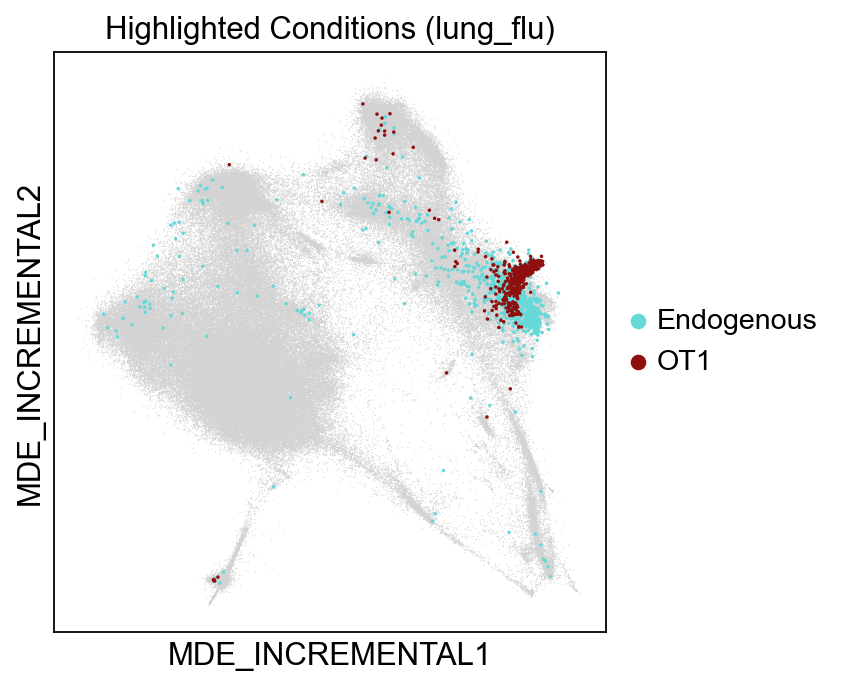

Plot saved: Fig_5d.pdf


In [34]:
# Fig. 5d — MDE plot with IGT95 and IGT96 cells from lung_flu highlighted
color_palette = {
    'OT1': "#8f0f0f",  # Deep red
    'Endogenous': "#65d8d8",    # Cyan
    # Add other categories in condition_detailed if necessary
}

# Filter for IGT == IGT95, IGT96 and condition_detailed_organ == 'lung_flu'
subset_conditions = rna[
    (rna.obs['IGT'].isin(['IGT95', 'IGT96'])) & 
    (rna.obs['condition_detailed_organ'].str.contains('lung_flu', na=False))
].copy()

# Create figure and axis
fig, ax = plt.subplots(figsize=(5.5, 4.5))

# Plot all cells in gray as background
sc.pl.embedding(
    rna,
    basis='MDE_INCREMENTAL',
    color='condition_broad',
    palette=['#d3d3d3'],  # Gray color for all cells
    size=1,  # Smaller point size for background
    show=False,
    ax=ax,
    legend_loc=None  # Remove legend
)

# Overlay cells from specified conditions
sc.pl.embedding(
    subset_conditions,
    basis='MDE_INCREMENTAL',
    color='Ag_spe_v1',  # Color by condition_detailed
    groups=['Endogenous', 'OT1'],  # Ensure only specified TG cells are colored
    palette=color_palette,  # Use defined color palette
    title='Highlighted Conditions (lung_flu)',
    legend_loc='right margin',
    size=10,  # Larger point size for foreground
    show=False,
    ax=ax
)

# Save and show the plot
plt.tight_layout()
plt.savefig("Fig_5d.pdf", bbox_inches="tight")
plt.show()
plt.close()
print("Plot saved: Fig_5d.pdf")


Plotting 9 organ entries:
  - submandibular gland: 1462 cells (IGT38/40)
  - prostate gland: 953 cells (IGT38/40)
  - lamina propria of small intestine: 394 cells (IGT38/40)
  - epithelium of small intestine: 319 cells (IGT38/40)
  - bone marrow: 141 cells (IGT38/40)
  - spleen (healthy): 60 cells (healthy)
  - mediastinal lymph node: 36 cells (IGT38/40)
  - mesenteric lymph node: 34 cells (IGT38/40)
  - spleen (IGT38/40): 10 cells (IGT38/40 (forced))
Plotting 32 genes (top 15 up/down + extras, ALL sorted by log2FC descending).


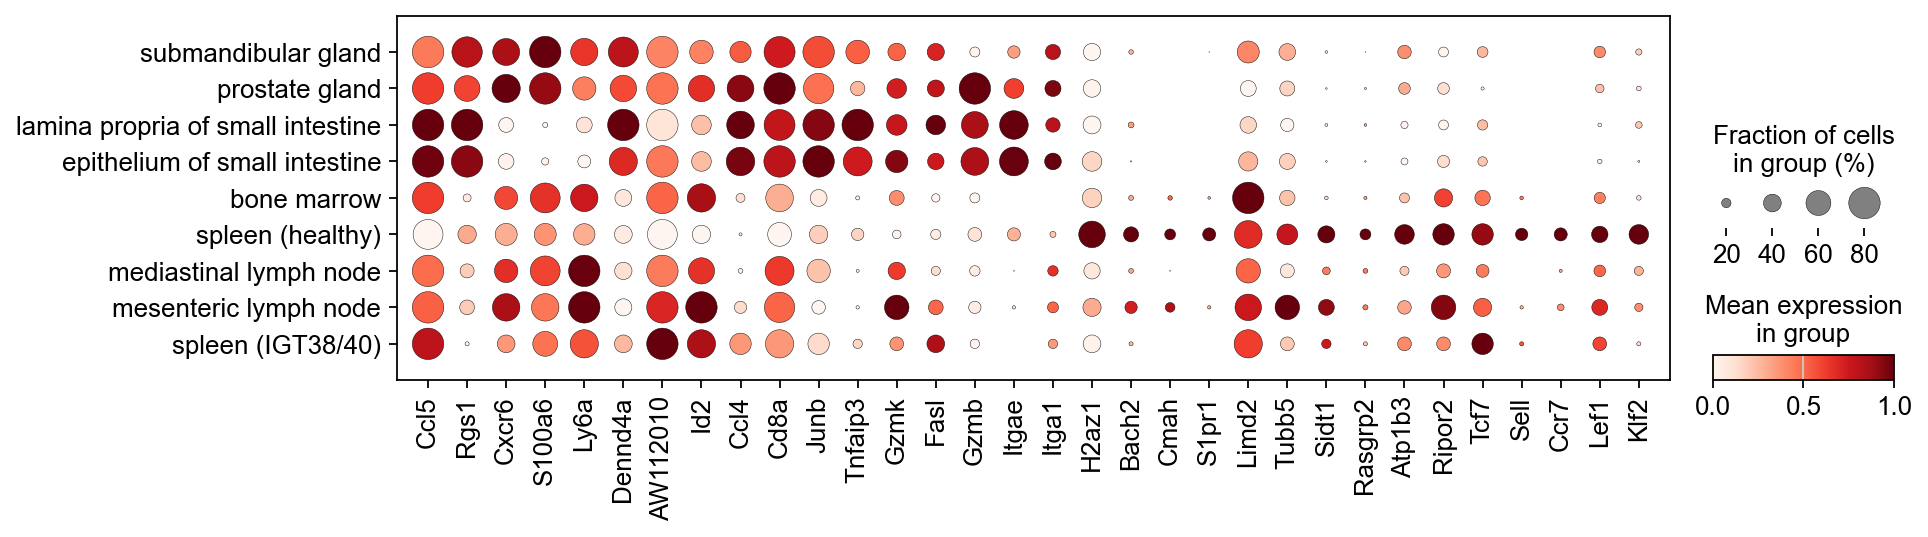

Balloon plot saved to: figures/Fig_5h.pdf


In [35]:
# Fig. 5h — Balloon plot of CD8.Q across tissues
import os
import scanpy as sc
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

# Custom color for CD8.Q
custom_colors = {
    'CD8.Q': '#76EE00',
}

def generate_balloon_plot_CD8_Q_IGT38_by_organ(
    main_signature_file,
    mdata,
    cluster='CD8.Q',
    pval_threshold=0.05,
    log2fc_threshold=0.5,
    top_n_genes=15,
    extra_genes=None,
    min_cells_per_organ=10,
    figures_dir='figures'
):
    """
    Balloon plot for CD8.Q:
    - Non-spleen organs: CD8.Q cells from IGT38/IGT40 only, with >10 cells
    - Spleen (healthy): ONLY healthy spleen CD8.Q cells
    - Spleen (non-healthy): CD8.Q cells from spleen in IGT38/IGT40 (if >10 cells)
    - X-axis gene order:
        - Top 15 upregulated (highest → lowest log2FC)
        - Top 15 downregulated (15th → 1st most significant)
        - Extra genes are fully integrated and sorted together with the top genes by log2FC
    """
    adata_all = mdata['RNA']
    os.makedirs(figures_dir, exist_ok=True)

    # ==============================================================
    # 1. Non-spleen organs: CD8.Q + IGT38/IGT40
    # ==============================================================
    cluster_mask = adata_all.obs['cluster_annotation'] == cluster
    igt_mask = adata_all.obs['IGT'].isin(['IGT38', 'IGT40'])
    non_spleen_mask = adata_all.obs['organ'] != 'spleen'

    adata_nonspleen = adata_all[cluster_mask & igt_mask & non_spleen_mask].copy()

    # ==============================================================
    # 2. Spleen non-healthy (IGT38/IGT40)
    # ==============================================================
    spleen_mask = adata_all.obs['organ'] == 'spleen'
    adata_spleen_nonhealthy = adata_all[cluster_mask & igt_mask & spleen_mask].copy()

    # ==============================================================
    # 3. Spleen healthy
    # ==============================================================
    healthy_mask = adata_all.obs['condition_broad'] == 'healthy'
    adata_spleen_healthy = adata_all[cluster_mask & spleen_mask & healthy_mask].copy()

    # ==============================================================
    # 4. Combine all parts
    # ==============================================================
    adata_list = []
    if adata_nonspleen.n_obs > 0:
        adata_list.append(adata_nonspleen)
    if adata_spleen_nonhealthy.n_obs > 0:
        adata_list.append(adata_spleen_nonhealthy)
    if adata_spleen_healthy.n_obs > 0:
        adata_list.append(adata_spleen_healthy)

    if not adata_list:
        print("No CD8.Q cells found matching the criteria.")
        return

    adata_plot = sc.concat(adata_list, label="source", keys=["nonspleen", "spleen_nonhealthy", "spleen_healthy"])

    # Use normalized scaled data
    if 'scaled' in adata_plot.layers:
        adata_plot.X = adata_plot.layers['scaled']
    elif 'log_norm' in adata_plot.layers:
        adata_plot.X = adata_plot.layers['log_norm']

    # ==============================================================
    # 5. Create display labels for spleen
    # ==============================================================
    adata_plot.obs['organ_plot'] = adata_plot.obs['organ'].astype(str)

    spleen_healthy_idx = (adata_plot.obs['organ'] == 'spleen') & (adata_plot.obs['source'] == 'spleen_healthy')
    spleen_nonhealthy_idx = (adata_plot.obs['organ'] == 'spleen') & (adata_plot.obs['source'] == 'spleen_nonhealthy')

    adata_plot.obs.loc[spleen_healthy_idx, 'organ_plot'] = 'spleen (healthy)'
    adata_plot.obs.loc[spleen_nonhealthy_idx, 'organ_plot'] = 'spleen (IGT38/40)'

    # ==============================================================
    # 6. Count and filter organs
    # ==============================================================
    organ_counts = adata_plot.obs['organ_plot'].value_counts()

    valid_organs = organ_counts[
        (organ_counts > min_cells_per_organ) |
        (organ_counts.index.str.contains('spleen'))
    ].index.tolist()

    if not valid_organs:
        print("No organs passed filtering.")
        return

    adata_plot = adata_plot[adata_plot.obs['organ_plot'].isin(valid_organs)].copy()

    ordered_organs = organ_counts.loc[valid_organs].sort_values(ascending=False).index.tolist()

    print(f"Plotting {len(ordered_organs)} organ entries:")
    for org in ordered_organs:
        count = organ_counts[org]
        source = "healthy" if 'healthy' in org else "IGT38/40"
        marker = " (forced)" if 'spleen' in org and count <= min_cells_per_organ else ""
        print(f"  - {org}: {count} cells ({source}{marker})")

    # ==============================================================
    # 7. Load DE results and build gene list
    # ==============================================================
    signature_df = pd.read_csv(main_signature_file, sep='\t', encoding='utf-8')
    
    log2fc_col = f'log2FC_{cluster}_vs_All'
    pval_col = f'adj.P.Val_{cluster}_vs_All'
    
    if log2fc_col not in signature_df.columns or pval_col not in signature_df.columns:
        raise ValueError(f"Columns for {cluster} not found in signature file.")

    plot_df = signature_df[['SYMBOL', log2fc_col, pval_col]].copy()
    plot_df['gene'] = plot_df['SYMBOL']
    plot_df['log2FC'] = plot_df[log2fc_col]

    significant = plot_df[
        (plot_df[pval_col] < pval_threshold) &
        (abs(plot_df['log2FC']) > log2fc_threshold)
    ].copy()

    if significant.empty:
        print(f"No significant genes for {cluster} with current thresholds.")
        return

    # Top 15 upregulated: highest → lowest
    top_up = significant[significant['log2FC'] > 0].sort_values('log2FC', ascending=False).head(top_n_genes)

    # Top 15 downregulated: select most significant (lowest log2FC), then reverse for plotting
    top_down_significant = significant[significant['log2FC'] < 0].sort_values('log2FC', ascending=True).head(top_n_genes)
    top_down_plot = top_down_significant.sort_values('log2FC', ascending=False)  # 15th → 1st

    # Start with the ordered top genes
    gene_order_df = pd.concat([top_up, top_down_plot])

    # Add extra genes (with their real log2FC if available)
    if extra_genes is not None:
        extra_df = plot_df[plot_df['gene'].isin(extra_genes)].copy()
        if not extra_df.empty:
            gene_order_df = pd.concat([gene_order_df, extra_df])

    # Remove duplicates and sort ALL together by log2FC descending
    gene_order_df = gene_order_df.drop_duplicates(subset='gene')
    gene_order_df = gene_order_df.sort_values('log2FC', ascending=False)

    gene_order = gene_order_df['gene'].tolist()

    # Keep only present genes
    gene_order = [g for g in gene_order if g in adata_plot.var_names]

    if not gene_order:
        print("None of the selected genes are present.")
        return

    print(f"Plotting {len(gene_order)} genes (top {top_n_genes} up/down + extras, ALL sorted by log2FC descending).")

    # Custom colormap
    cluster_color = custom_colors.get(cluster, '#76EE00')
    custom_cmap = LinearSegmentedColormap.from_list(
        f'white_to_{cluster}', ['#FFFFFF', cluster_color], N=256
    )

    # ==============================================================
    # 8. Balloon plot
    # ==============================================================
    sc.pl.dotplot(
        adata_plot,
        var_names=gene_order,
        groupby='organ_plot',
        categories_order=ordered_organs,
        cmap='Reds',
        standard_scale='var',
        dot_min=0.05,
        dot_max=0.8,
        figsize=(12, 3),
        save=f'Fig_5h.pdf'
    )

    print(f"Balloon plot saved to: {figures_dir}/Fig_5h.pdf")


# ==========================
# Usage
# ==========================

main_signature_file = 'data/ttlist_OneVsAll.txt'

generate_balloon_plot_CD8_Q_IGT38_by_organ(
    main_signature_file=main_signature_file,
    mdata=mdata,
    top_n_genes=15,
    extra_genes=['Itgae', 'Itga1'],
    min_cells_per_organ=10,
    figures_dir='figures'
)

In [36]:
# Fig. 5j - GP analysis across tissues within CD8.Q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming mdata is your MuData object containing the AnnData
# Load matrices (adjust paths as needed)
F_df = pd.read_csv("data/gene_factor_matrix.txt", sep="\t", index_col=0)
L_df = pd.read_csv("data/cell_factor_matrix.txt.gz", sep="\t", index_col=0, compression="gzip")

# Convert to NumPy arrays for efficient computation
F_np = F_df.to_numpy()
L_np = L_df.to_numpy()

# Preserve names
factor_names = L_df.columns  # e.g., F1–F200
gene_names = F_df.index

# Verify shapes
print("F_np shape:", F_np.shape)  # Expected: (19805, 200)
print("L_np shape:", L_np.shape)  # Expected: (682953, 200)

# Access observations from the AnnData
mdata_obs = mdata['RNA'].obs

# Check for cell ID column
if 'cellID' in mdata_obs.columns:
    print("Using 'cellID' from mdata_obs")
    cell_id_col = 'cellID'
else:
    print("Using 'IGT_cellID' from mdata_obs")
    cell_id_col = 'IGT_cellID'

# Subset to IGT == 'IGT38' and exclude condition_broad == 'healthy'
igt38_obs = mdata_obs[(mdata_obs['IGT'] == 'IGT38') & (mdata_obs['condition_broad'] != 'healthy')]

# Get unique detailed organs and filter by cell count (>= 50 cells)
organ_cell_counts = igt38_obs['condition_detailed_organ'].value_counts()
unique_organs = organ_cell_counts[organ_cell_counts >= 50].index.tolist()
print(f"Found {len(unique_organs)} unique detailed organs in IGT38 (non-healthy) with >= 50 cells: {unique_organs}")

# Optional: Sort organs if needed (e.g., alphabetically)
unique_organs = sorted(unique_organs)

# Function to compute log2FC for a group vs others
def compute_factor_log2fc(L_np, group1, group2, factor_names):
    group1 = [g for g in group1 if g in L_df.index]
    group2 = [g for g in group2 if g in L_df.index]
    if not group1 or not group2:
        return None
    group1_idx = [L_df.index.get_loc(g) for g in group1]
    group2_idx = [L_df.index.get_loc(g) for g in group2]
    loadings_group1 = L_np[group1_idx].mean(axis=0)
    loadings_group2 = L_np[group2_idx].mean(axis=0)
    fc_loadings = loadings_group1 - loadings_group2
    return pd.DataFrame({
        'SYMBOL': factor_names,
        'log2FC': fc_loadings / np.log(2)
    })

# Identify top factors for each detailed organ within IGT38 (non-healthy)
top_factors_per_organ = {}
n_top = 1  # Top 1 factor per organ; adjust as needed
for organ in unique_organs:
    group1 = igt38_obs[igt38_obs['condition_detailed_organ'] == organ][cell_id_col].tolist()
    group2 = igt38_obs[igt38_obs['condition_detailed_organ'] != organ][cell_id_col].tolist()
    if group1 and group2:
        log2fc_df = compute_factor_log2fc(L_np, group1, group2, factor_names)
        if log2fc_df is not None:
            top = log2fc_df.sort_values(by='log2FC', ascending=False).head(n_top)
            top_factors_per_organ[organ] = top['SYMBOL'].tolist()
            print(f"Top factor(s) for {organ}: {top['SYMBOL'].tolist()}")
    else:
        print(f"Skipping {organ}: group1 has {len(group1)} cells, group2 has {len(group2)} cells")

# Collect all unique top factors across organs
all_top_factors = list(dict.fromkeys([f for factors in top_factors_per_organ.values() for f in factors]))
print(f"All selected top factors: {all_top_factors}")

# Compute mean loadings for each organ and top factor
organ_loadings = []
for organ in unique_organs:
    group = igt38_obs[igt38_obs['condition_detailed_organ'] == organ][cell_id_col].tolist()
    if group:
        group_idx = [L_df.index.get_loc(g) for g in group if g in L_df.index]
        if group_idx:
            loadings = L_np[group_idx].mean(axis=0)
            for i, factor in enumerate(factor_names):
                if factor in all_top_factors:
                    organ_loadings.append({
                        'organ': organ,
                        'factor': factor,
                        'mean_loading': loadings[i],
                        'num_cells': len(group)
                    })
        else:
            print(f"Skipping {organ}: no valid cells")
    else:
        print(f"Skipping {organ}: no valid cells")

# Convert to DataFrame
loadings_df = pd.DataFrame(organ_loadings)

# Pivot for visualization (organs as rows, factors as columns)
pivot_df = loadings_df.pivot(index='organ', columns='factor', values='mean_loading').fillna(0)

# Reindex to sorted organs
pivot_df = pivot_df.reindex(unique_organs)

# Print the pivot table
print(pivot_df)


F_np shape: (19805, 200)
L_np shape: (682953, 200)
Using 'IGT_cellID' from mdata_obs
Found 8 unique detailed organs in IGT38 (non-healthy) with >= 50 cells: ['salivarygland_LCMVarm_D30', 'LNmediastinal_LCMVarm_D30', 'LNmesenteric_LCMVarm_D30', 'bonemarrow_LCMVarm_D30', 'spleen_LCMVarm_D30', 'prostate_LCMVarm_D30', 'smallintestineLP_LCMVarm_D30', 'smallintestineIEL_LCMVarm_D30']
Top factor(s) for LNmediastinal_LCMVarm_D30: ['F58']
Top factor(s) for LNmesenteric_LCMVarm_D30: ['F58']
Top factor(s) for bonemarrow_LCMVarm_D30: ['F80']
Top factor(s) for prostate_LCMVarm_D30: ['F26']
Top factor(s) for salivarygland_LCMVarm_D30: ['F26']
Top factor(s) for smallintestineIEL_LCMVarm_D30: ['F35']
Top factor(s) for smallintestineLP_LCMVarm_D30: ['F35']
Top factor(s) for spleen_LCMVarm_D30: ['F10']
All selected top factors: ['F58', 'F80', 'F26', 'F35', 'F10']
factor                              F10       F26       F35       F58  \
organ                                                                

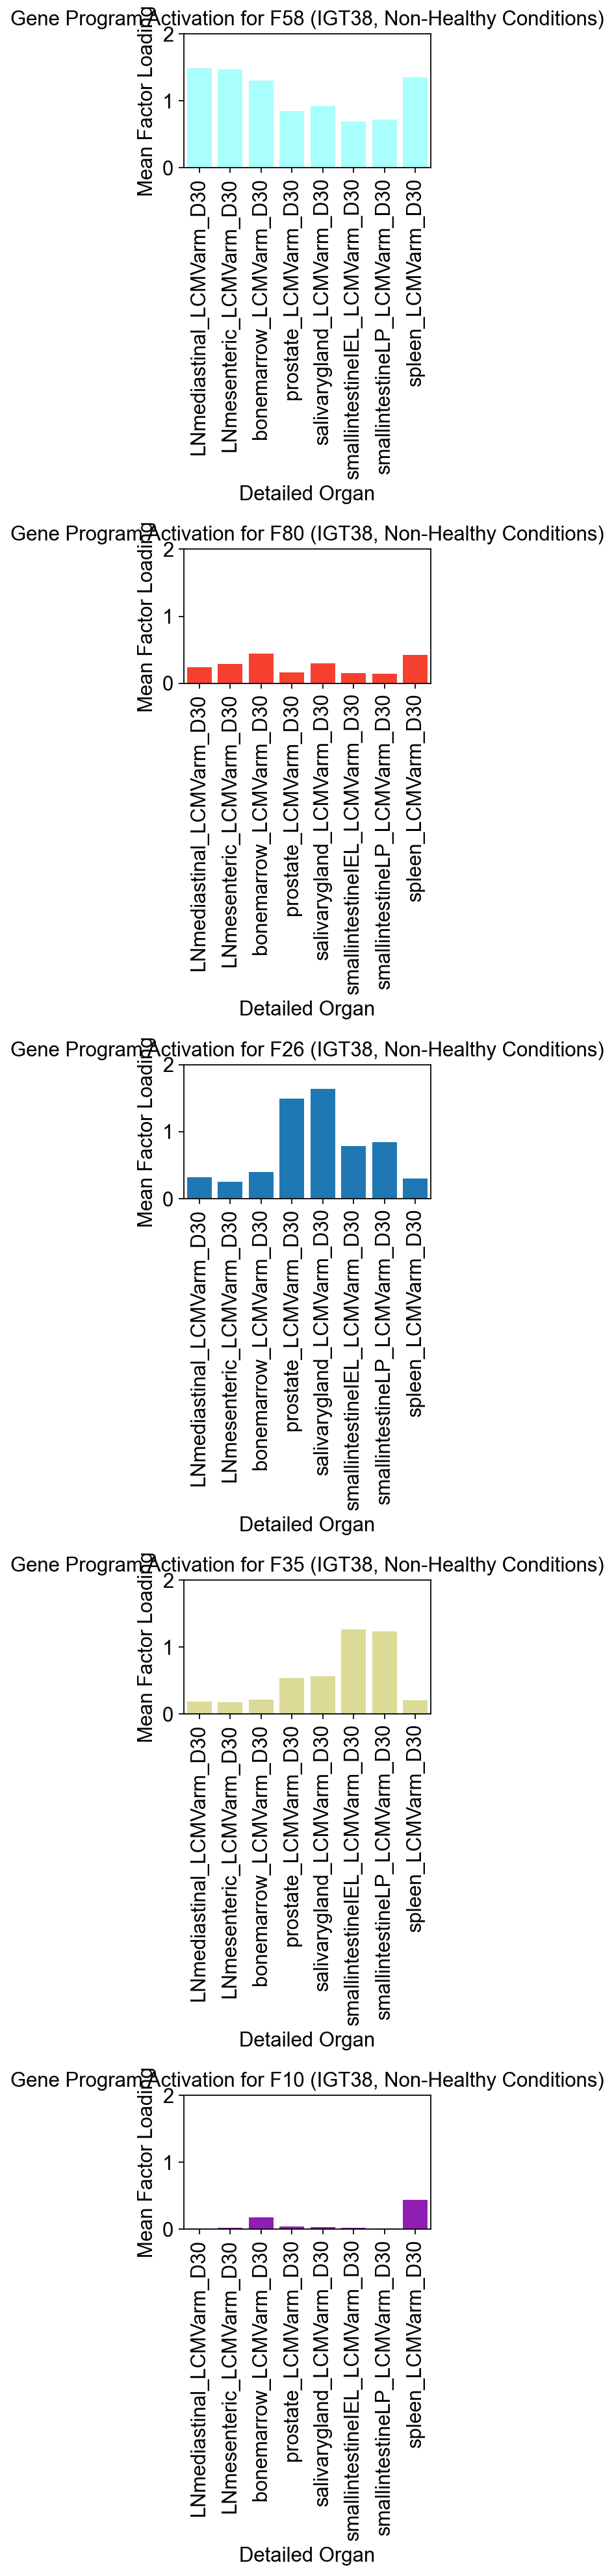

In [37]:
# Fig. 5j - GP analysis across tissues within CD8.Q
import matplotlib.pyplot as plt
import numpy as np

# Assuming pivot_df, all_top_factors, and unique_organs are defined from the previous code
# pivot_df: DataFrame with organs as index and factors as columns, filtered to organs with >= 50 cells
# all_top_factors: List of unique top factors across organs
# unique_organs: List of unique condition_detailed_organ values with >= 50 cells
# No target_clusters equivalent; we won't highlight specific organs unless specified

# Create a figure with subplots (one subplot per factor)
fig, axes = plt.subplots(nrows=len(all_top_factors), ncols=1, figsize=(3.5, 5 * len(all_top_factors)))

# Ensure axes is a list even if there's only one factor
if len(all_top_factors) == 1:
    axes = [axes]

# Colors for factors (distinct and theme-compatible)
colors = ["#a8fffb", "#f6402f", "#1f78b4", "#dcda97", "#8f1fb4"][:len(all_top_factors)]  # Up to 5 factors, add more colors if needed

# Plot a bar plot for each factor
for i, (factor, ax) in enumerate(zip(all_top_factors, axes)):
    # X positions for organs
    x = np.arange(len(unique_organs))
    # Plot bars for the current factor
    bars = ax.bar(x, pivot_df[factor], color=colors[i], label=factor)
    # Customize each subplot
    ax.set_xlabel('Detailed Organ')
    ax.set_ylabel('Mean Factor Loading')
    ax.set_title(f'Gene Program Activation for {factor} (IGT38, Non-Healthy Conditions)')
    ax.set_xticks(x)
    ax.set_ylim(0, 2)  # Adjust ylim if needed based on data
    ax.set_xticklabels(unique_organs, rotation=90, ha='center')  # Use filtered organ names, adjust rotation for readability
    ax.grid(False)  # Explicitly disable any grid
    # Reduce gaps before first bar and after last bar
    ax.set_xlim(-0.5, len(unique_organs) - 0.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save as PDF
plt.savefig('Fig_5j.pdf', dpi=300, bbox_inches='tight', format='pdf')

# Show the plot
plt.show()


Organs in IGT38 (non-healthy): ['LNmediastinal_LCMVarm_D30', 'LNmesenteric_LCMVarm_D30', 'bonemarrow_LCMVarm_D30', 'lung_LCMVarm_D30', 'prostate_LCMVarm_D30', 'salivarygland_LCMVarm_D30', 'smallintestineIEL_LCMVarm_D30', 'smallintestineLP_LCMVarm_D30', 'spleen_LCMVarm_D30']
Top factor(s) for LNmediastinal_LCMVarm_D30: ['F58']
Top factor(s) for LNmesenteric_LCMVarm_D30: ['F58']
Top factor(s) for bonemarrow_LCMVarm_D30: ['F80']
Top factor(s) for lung_LCMVarm_D30: ['F10']
Top factor(s) for prostate_LCMVarm_D30: ['F26']
Top factor(s) for salivarygland_LCMVarm_D30: ['F26']
Top factor(s) for smallintestineIEL_LCMVarm_D30: ['F35']
Top factor(s) for smallintestineLP_LCMVarm_D30: ['F35']
Top factor(s) for spleen_LCMVarm_D30: ['F10']
Selected factors: ['F58', 'F80', 'F10', 'F26', 'F35']
Top 10 genes for F58: ['Cd8b1', 'Cd8a', 'Nkg7', 'Ly6c2', 'Ctsw', 'Epsti1', 'Dnajc15', 'Cd4', 'CT010467.1', 'Klrd1']
Top 10 genes for F80: ['Ccl5', 'Klf2', 'Crip1', 'Itgb1', 'Ly6c2', 'Ahnak', 'S100a6', 'S100a10', 

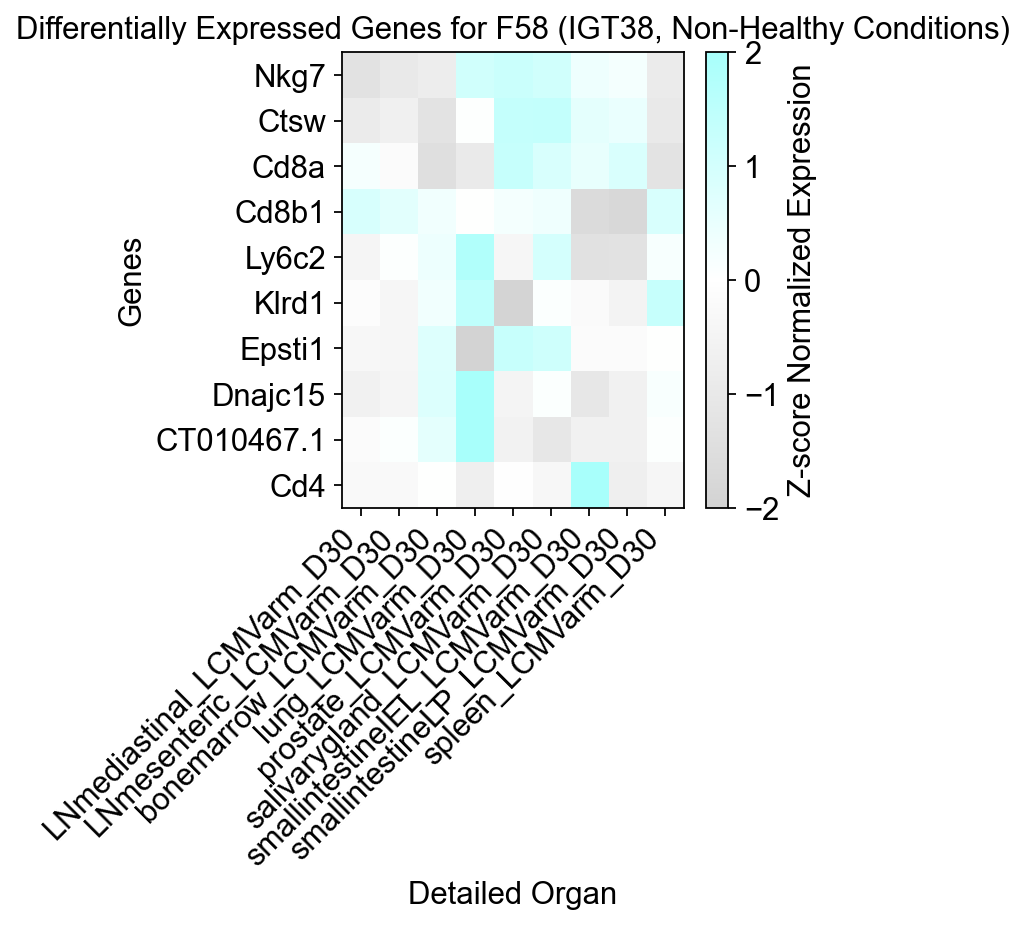

Plot saved: Fig_5j_v2_F58.pdf


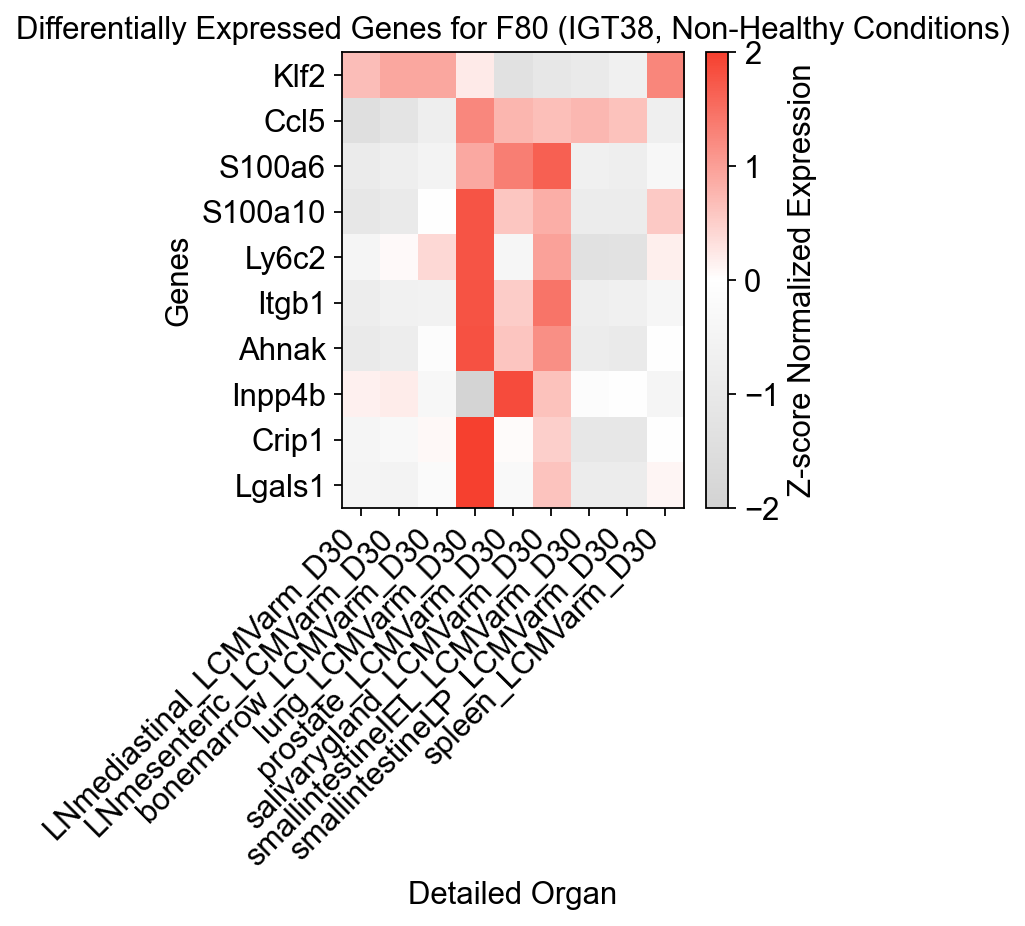

Plot saved: Fig_5j_v2_F80.pdf


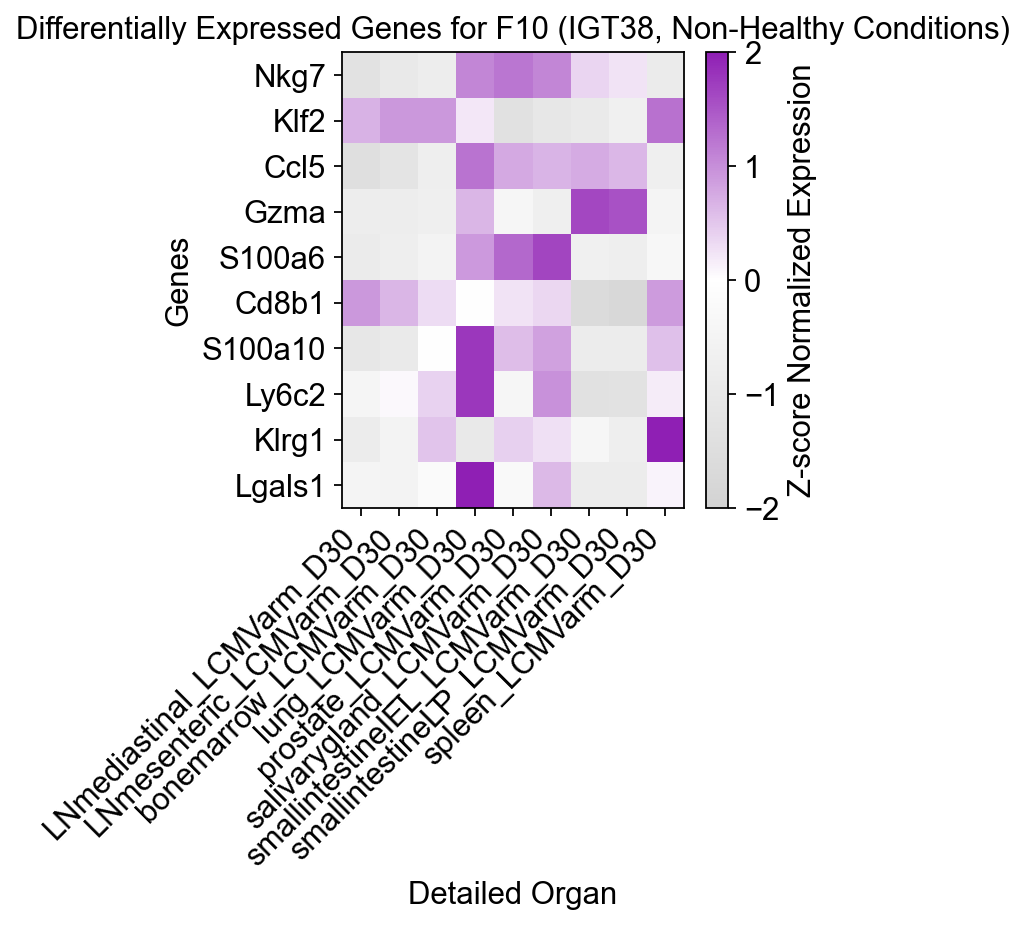

Plot saved: Fig_5j_v2_F10.pdf


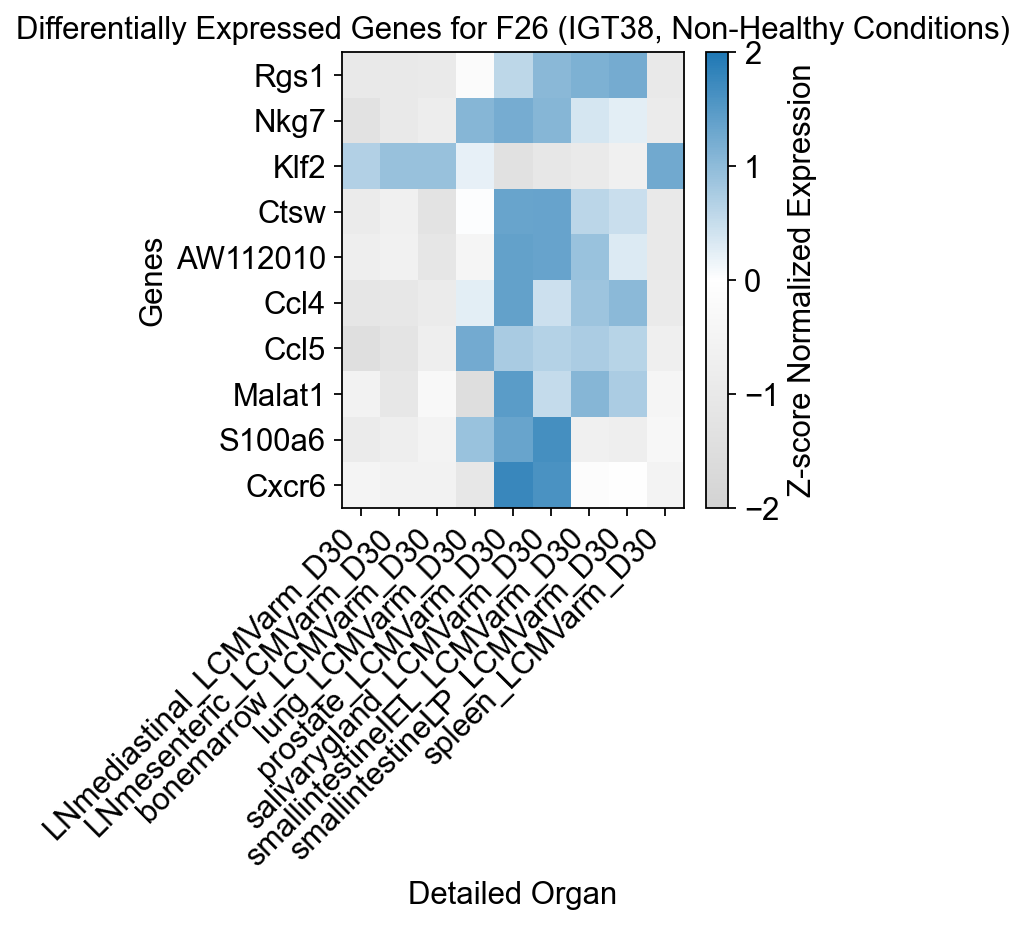

Plot saved: Fig_5j_v2_F26.pdf


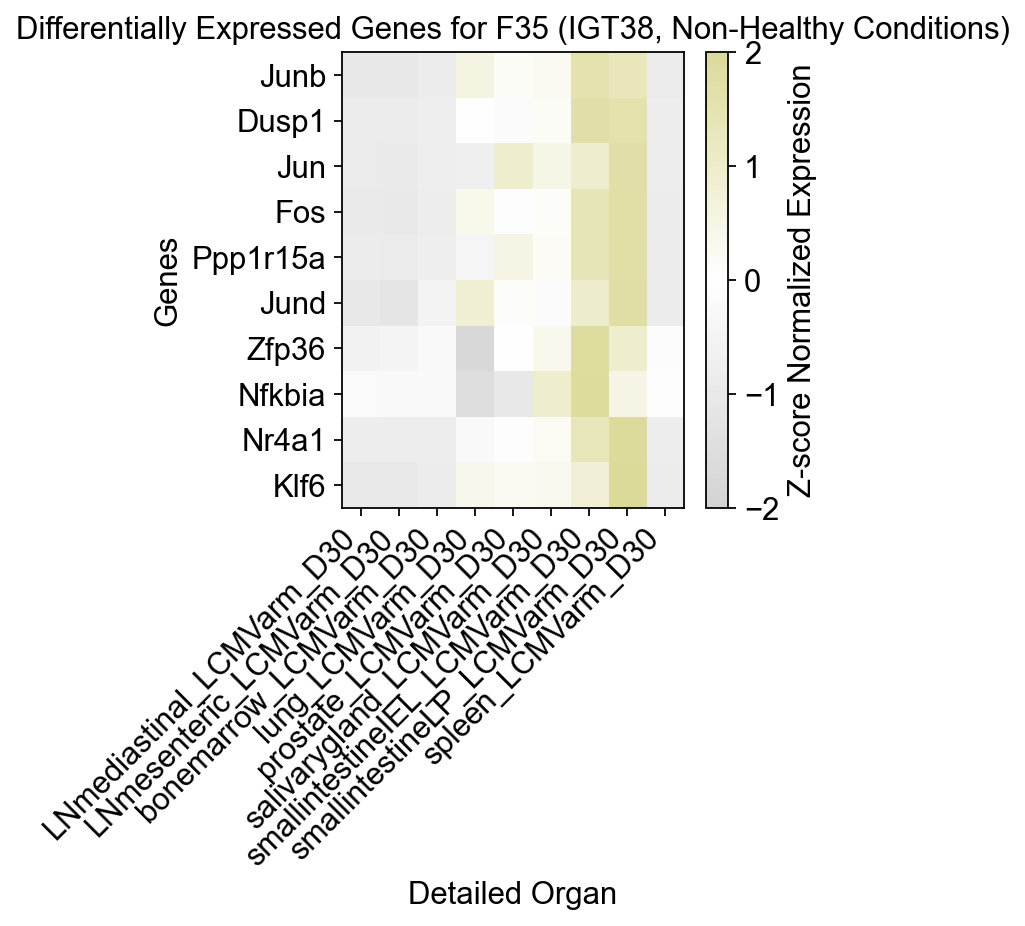

Plot saved: Fig_5j_v2_F35.pdf

Z-score normalized gene expression for all genes:
organ       LNmediastinal_LCMVarm_D30  LNmesenteric_LCMVarm_D30  \
gene                                                              
AW112010                    -0.764040                 -0.609132   
Ahnak                       -0.918739                 -0.800959   
CT010467.1                  -0.162635                  0.080865   
Ccl4                        -1.102162                 -1.065959   
Ccl5                        -1.418558                 -1.206986   
Cd4                         -0.237994                 -0.239746   
Cd8a                         0.214783                 -0.153663   
Cd8b1                        0.921326                  0.655688   
Crip1                       -0.410368                 -0.304297   
Ctsw                        -0.895644                 -0.659940   
Cxcr6                       -0.496510                 -0.546968   
Dnajc15                     -0.595062           

In [38]:
# Fig. 5j - GP analysis across tissues within CD8.Q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.sparse as sparse

# Ensure we use your preferred normalized data
mdata['RNA'].X = mdata['RNA'].layers['scaled']

# Recompute top factors (self-contained block)
def compute_factor_log2fc(L_np, group1, group2, factor_names):
    group1 = [g for g in group1 if g in L_df.index]
    group2 = [g for g in group2 if g in L_df.index]
    if not group1 or not group2:
        return None
    group1_idx = [L_df.index.get_loc(g) for g in group1]
    group2_idx = [L_df.index.get_loc(g) for g in group2]
    loadings_group1 = L_np[group1_idx].mean(axis=0)
    loadings_group2 = L_np[group2_idx].mean(axis=0)
    fc_loadings = loadings_group1 - loadings_group2
    return pd.DataFrame({
        'SYMBOL': factor_names,
        'log2FC': fc_loadings / np.log(2)
    })

# Filter for IGT38 non-healthy (assuming already defined as igt38_obs)
# If not, define it here for safety
if 'igt38_obs' not in globals():
    igt38_obs = mdata_obs[(mdata_obs['IGT'] == 'IGT38') & (mdata_obs['condition_broad'] != 'healthy')]

unique_organs = sorted(igt38_obs['condition_detailed_organ'].unique())
print(f"Organs in IGT38 (non-healthy): {unique_organs}")

# Identify top factors for each detailed organ within IGT38 (non-healthy)
top_factors_per_organ = {}
n_top = 1  # Top 1 factor per organ
for organ in unique_organs:
    group1 = igt38_obs[igt38_obs['condition_detailed_organ'] == organ][cell_id_col].tolist()
    group2 = igt38_obs[igt38_obs['condition_detailed_organ'] != organ][cell_id_col].tolist()
    if group1 and group2:
        log2fc_df = compute_factor_log2fc(L_np, group1, group2, factor_names)
        if log2fc_df is not None:
            top = log2fc_df.sort_values(by='log2FC', ascending=False).head(n_top)
            top_factors_per_organ[organ] = top['SYMBOL'].tolist()
            print(f"Top factor(s) for {organ}: {top['SYMBOL'].tolist()}")
    else:
        print(f"Skipping {organ}: insufficient cells")

# Collect all unique top factors
all_top_factors = list(dict.fromkeys([f for factors in top_factors_per_organ.values() if factors for f in factors]))
print(f"Selected factors: {all_top_factors}")

# Verify we have 5 factors
if len(all_top_factors) != 5:
    print(f"Warning: Found {len(all_top_factors)} factors instead of 5: {all_top_factors}")

# Extract top genes for each selected factor
n_top_genes = 10
factor_genes = {factor: [] for factor in all_top_factors}
for factor in all_top_factors:
    factor_idx = list(factor_names).index(factor)
    gene_loadings = pd.Series(F_np[:, factor_idx], index=gene_names)
    top = gene_loadings.abs().sort_values(ascending=False).head(n_top_genes)
    factor_genes[factor] = top.index.tolist()
    print(f"Top {n_top_genes} genes for {factor}: {top.index.tolist()}")

# === REAL average expression per organ (trusted method) ===
# Create a boolean mask over the FULL mdata['RNA'] object
full_mask = mdata_obs.index.isin(igt38_obs.index) & mdata_obs['condition_detailed_organ'].isin(unique_organs)

# Subset expression matrix using boolean mask (safe for AnnData/MuData)
subset_X = mdata['RNA'].X[full_mask]

# Subset obs accordingly
subset_obs = mdata_obs[full_mask]

# Get organ labels
organ_labels = subset_obs['condition_detailed_organ'].values

unique_labels, inverse = np.unique(organ_labels, return_inverse=True)
n_genes = subset_X.shape[1]

mean_expr_matrix = np.empty((len(unique_labels), n_genes))
for i, label in enumerate(unique_labels):
    mask_i = (inverse == i)
    if sparse.issparse(subset_X):
        mean_expr_matrix[i] = np.ravel(subset_X[mask_i].mean(axis=0))
    else:
        mean_expr_matrix[i] = subset_X[mask_i].mean(axis=0)

mean_expr_pivot = pd.DataFrame(
    mean_expr_matrix,
    index=unique_labels,
    columns=mdata['RNA'].var_names
).T  # genes x organs
mean_expr_pivot = mean_expr_pivot[unique_organs]  # Order correctly

# === Build expression DataFrame using REAL expression ===
gene_expression = []
for organ in unique_organs:
    for factor in all_top_factors:
        for gene in factor_genes[factor]:
            if gene in mean_expr_pivot.index:
                gene_expression.append({
                    'organ': organ,
                    'gene': gene,
                    'mean_expr': mean_expr_pivot.loc[gene, organ],
                    'factor': factor
                })

expr_df = pd.DataFrame(gene_expression)

# Create custom colormaps for 5 factors
colors = [
    ['lightgray', 'white', '#a8fffb'],  # light blue
    ['lightgray', 'white', '#f6402f'],  # red
    ['lightgray', 'white', '#8f1fb4'],  # dark blue
    ['lightgray', 'white', '#1f78b4'],  # yellow
    ['lightgray', 'white', '#dcda97']   # purple
]
cmaps = [LinearSegmentedColormap.from_list(f'custom_{i+1}', colors[i]) for i in range(5)]

# Set z-score range
zscore_min = -2.0
zscore_max = 2.0

# Create heatmaps for each factor
for i, factor in enumerate(all_top_factors):
    factor_expr_df = expr_df[expr_df['factor'] == factor]
    pivot_df = factor_expr_df.pivot(index='gene', columns='organ', values='mean_expr').fillna(0)
    pivot_df = pivot_df[unique_organs]

    # Z-score normalization per gene
    pivot_df = pivot_df.apply(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else x, axis=1)

    # Order genes by max abs z-score
    pivot_df = pivot_df.loc[pivot_df.abs().max(axis=1).sort_values(ascending=False).index]

    cmap = cmaps[i]

    fig, ax = plt.subplots(figsize=(5.25, 6))
    heatmap = ax.imshow(pivot_df.values, cmap=cmap, aspect='auto',
                        vmin=zscore_min, vmax=zscore_max, interpolation='nearest')
    ax.invert_yaxis()

    ax.set_xticks(np.arange(len(unique_organs)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(unique_organs, rotation=45, ha='right')
    ax.set_yticklabels(pivot_df.index)
    ax.set_xlabel('Detailed Organ')
    ax.set_ylabel('Genes')
    ax.set_title(f'Differentially Expressed Genes for {factor} (IGT38, Non-Healthy Conditions)')
    ax.grid(False)

    plt.colorbar(heatmap, label='Z-score Normalized Expression')
    plt.tight_layout()
    plt.savefig(f'Fig_5j_v2_{factor}.pdf', format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f'Plot saved: Fig_5j_v2_{factor}.pdf')

# Print results
print("\nZ-score normalized gene expression for all genes:")
pivot_df = expr_df.groupby(['gene', 'organ'])['mean_expr'].first().unstack().fillna(0)[unique_organs]
pivot_df = pivot_df.apply(lambda x: (x - x.mean()) / x.std() if x.std() != 0 else x, axis=1)
print(pivot_df)


# Fig. 6

In [40]:
# Fig. 6a — MDE plots
cd44_neg = {'CD8.A', 'CD8.B', 'CD8.D', 'CD8.T', 'CD8.wM', 'CD8.wX'}

rna.obs['CD44_status'] = 'CD44+'
rna.obs.loc[rna.obs['cluster_annotation'].isin(cd44_neg), 'CD44_status'] = 'CD44-'

# Quick check
print(rna.obs['CD44_status'].value_counts(dropna=False))


CD44_status
CD44-    109242
CD44+     96918
Name: count, dtype: int64


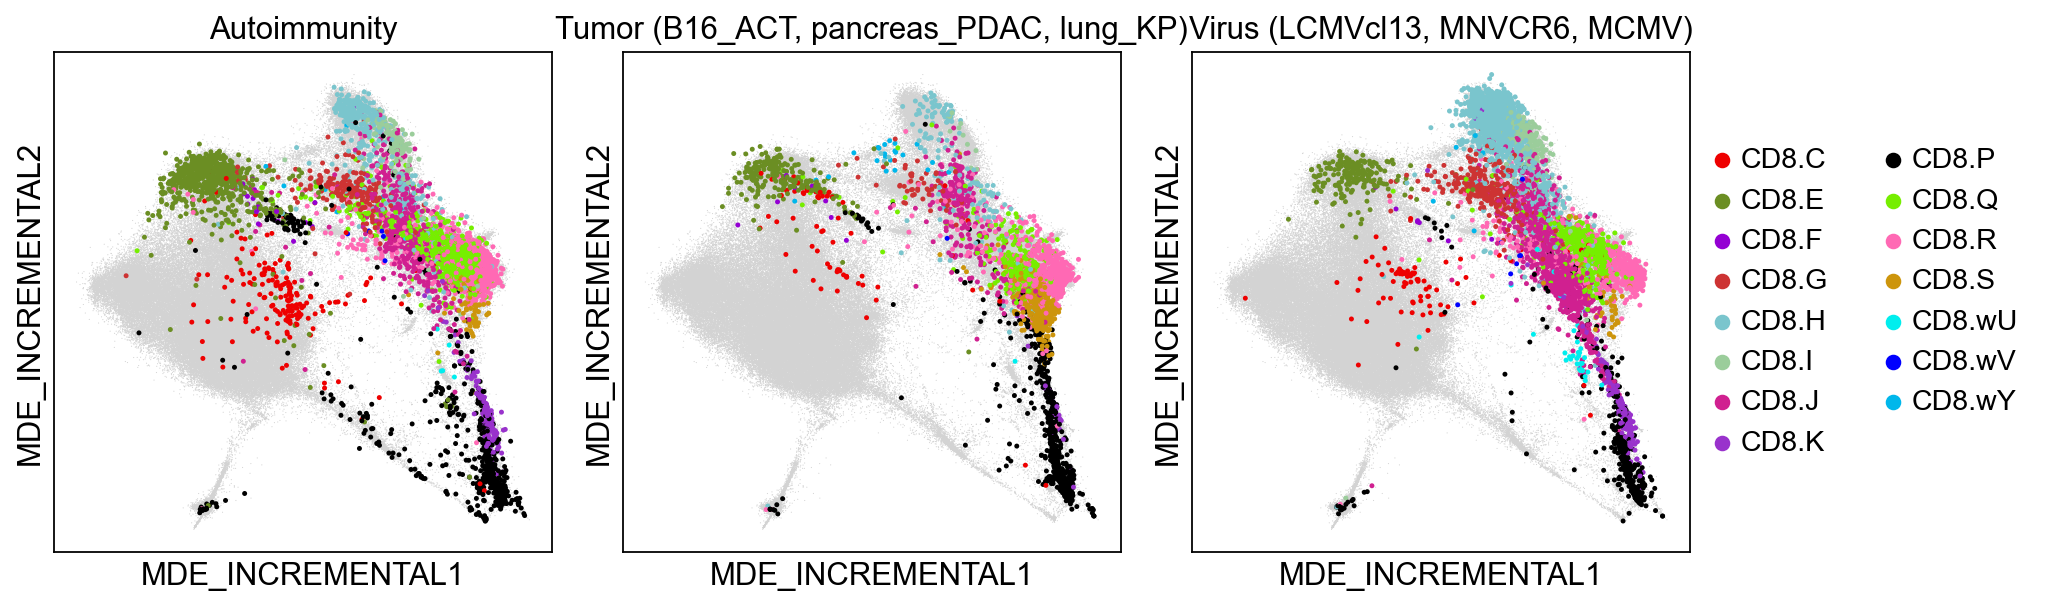

Plot saved: Fig_6a.pdf


In [41]:
# Fig. 6a — MDE plots
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# Gray background for non-highlighted cells
default_color = '#BAB0AC'

# List of the 3 conditions to highlight (one panel each)
conditions = [
    {
        'name': 'autoimmunity',
        'mask': (
            (rna.obs['condition_broad'].str.lower() == 'autoimmunity') &
            (rna.obs['CD44_status'] == 'CD44+')
        ),
        'title': 'Autoimmunity'
    },
    {
        'name': 'tumor',
        'mask': (
            (rna.obs['condition_broad'].str.lower() == 'tumor') &
            (rna.obs['condition_detailed_organ'].isin(['B16_ACT', 'pancreas_PDAC', 'lung_KP'])) &
            (rna.obs['Ag_spe_v1'] == 'Endogenous') &
            (rna.obs['CD44_status'] == 'CD44+')
        ),
        'title': 'Tumor (B16_ACT, pancreas_PDAC, lung_KP)'
    },
    {
        'name': 'virus_specific',
        'mask': (
            (rna.obs['condition_broad'].str.lower() == 'virus') &
            (rna.obs['condition_detailed_simplified'].isin(['LCMVcl13', 'MNVCR6', 'MCMV'])) &
            (rna.obs['CD44_status'] == 'CD44+')
        ),
        'title': 'Virus (LCMVcl13, MNVCR6, MCMV)'
    }
]

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for idx, cond in enumerate(conditions):
    # Create the highlight mask for this condition
    highlight_mask = cond['mask']
    
    # Color by cluster_annotation only for highlighted cells, else np.nan → will use na_color
    rna.obs['highlight_color'] = np.where(
        highlight_mask,
        rna.obs['cluster_annotation'],
        np.nan  # ← Changed from None to np.nan
    )
    
    # Make highlighted cells visibly larger
    sizes = np.where(highlight_mask, 20, 1)
    
    ax = axes[idx]
    sc.pl.embedding(
        rna,
        basis="MDE_INCREMENTAL",
        color="highlight_color",
        palette=custom_colors,
        na_in_legend=False,
        legend_loc="right margin" if idx == 2 else "none",
        ax=ax,
        size=sizes,
        title=cond['title'],
        show=False,
    )

plt.tight_layout()
plt.savefig("Fig_6a.pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Plot saved: Fig_6a.pdf")


Final unique conditions: 116


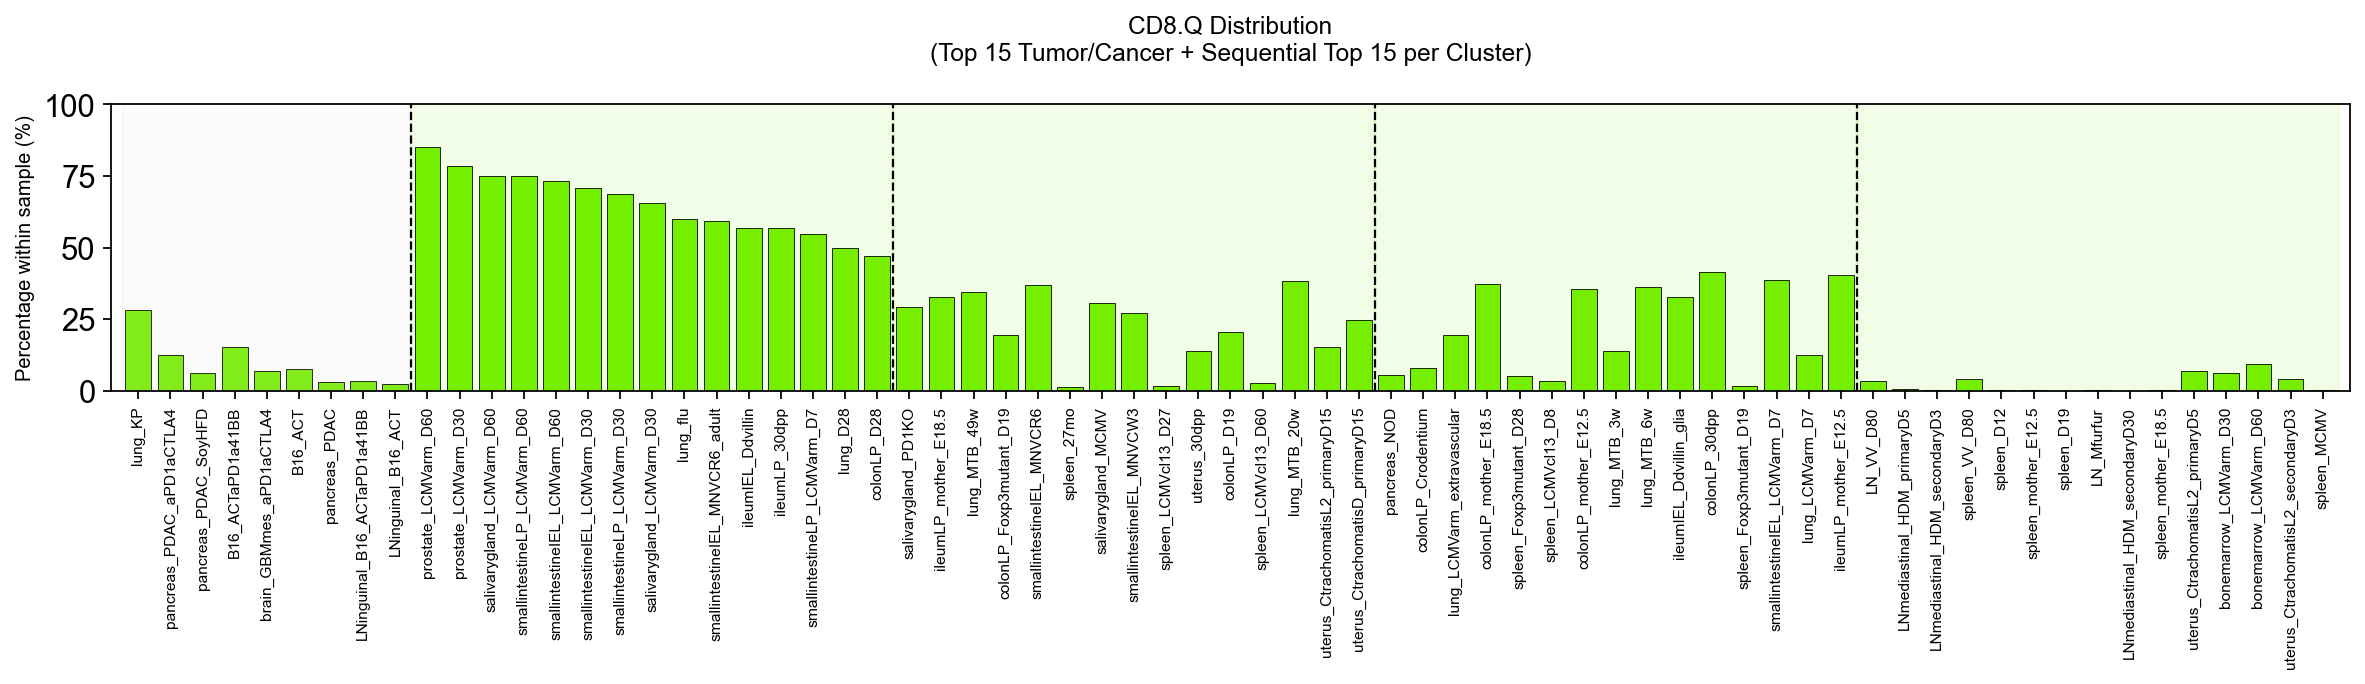

Saved: Fig_6d_CD8.Q.pdf
 → Tumor: 9 | Q: 15 | R: 15 | S: 15 | C: 15



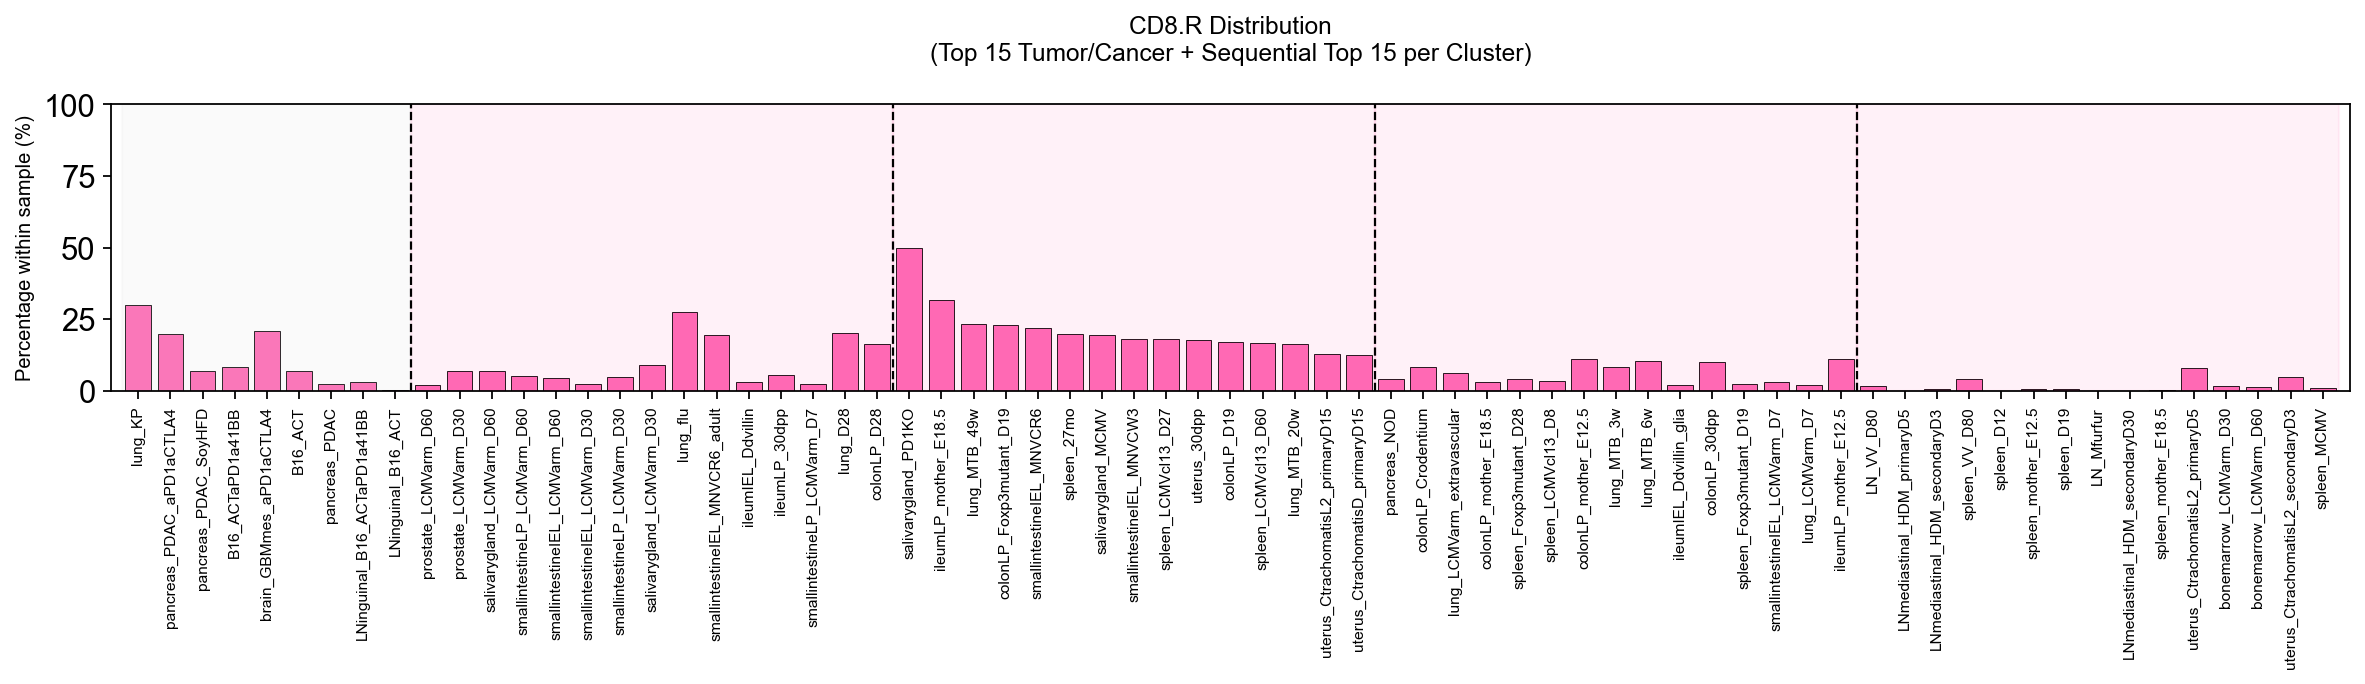

Saved: Fig_6d_CD8.R.pdf
 → Tumor: 9 | Q: 15 | R: 15 | S: 15 | C: 15



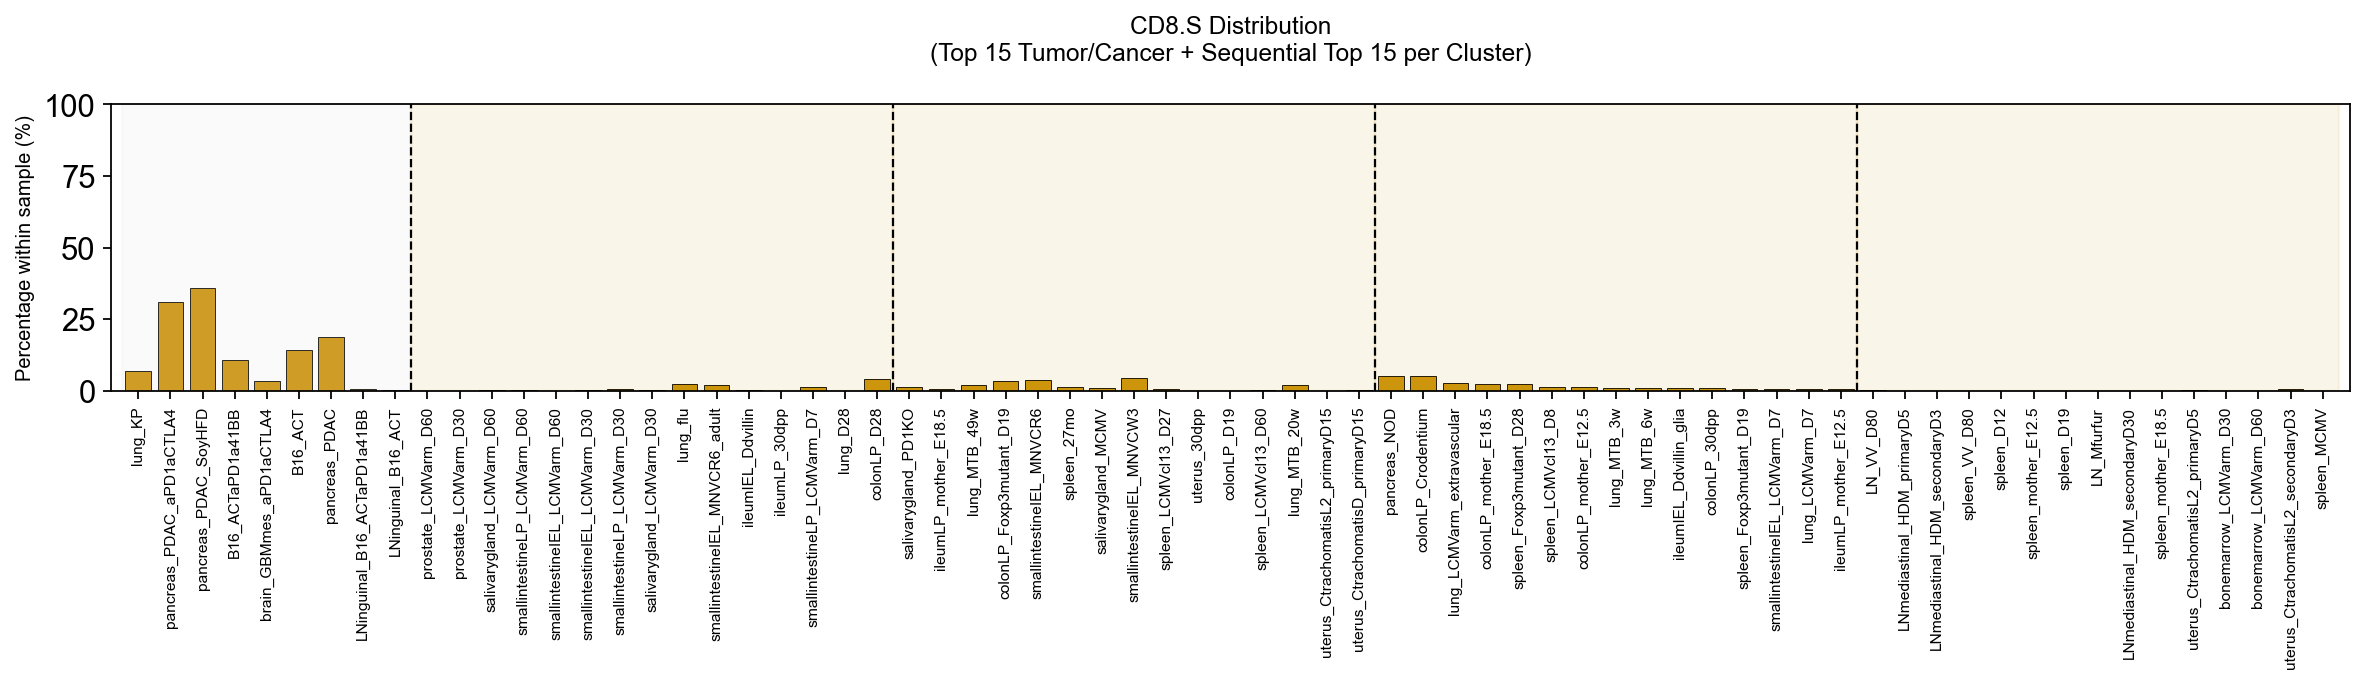

Saved: Fig_6d_CD8.S.pdf
 → Tumor: 9 | Q: 15 | R: 15 | S: 15 | C: 15



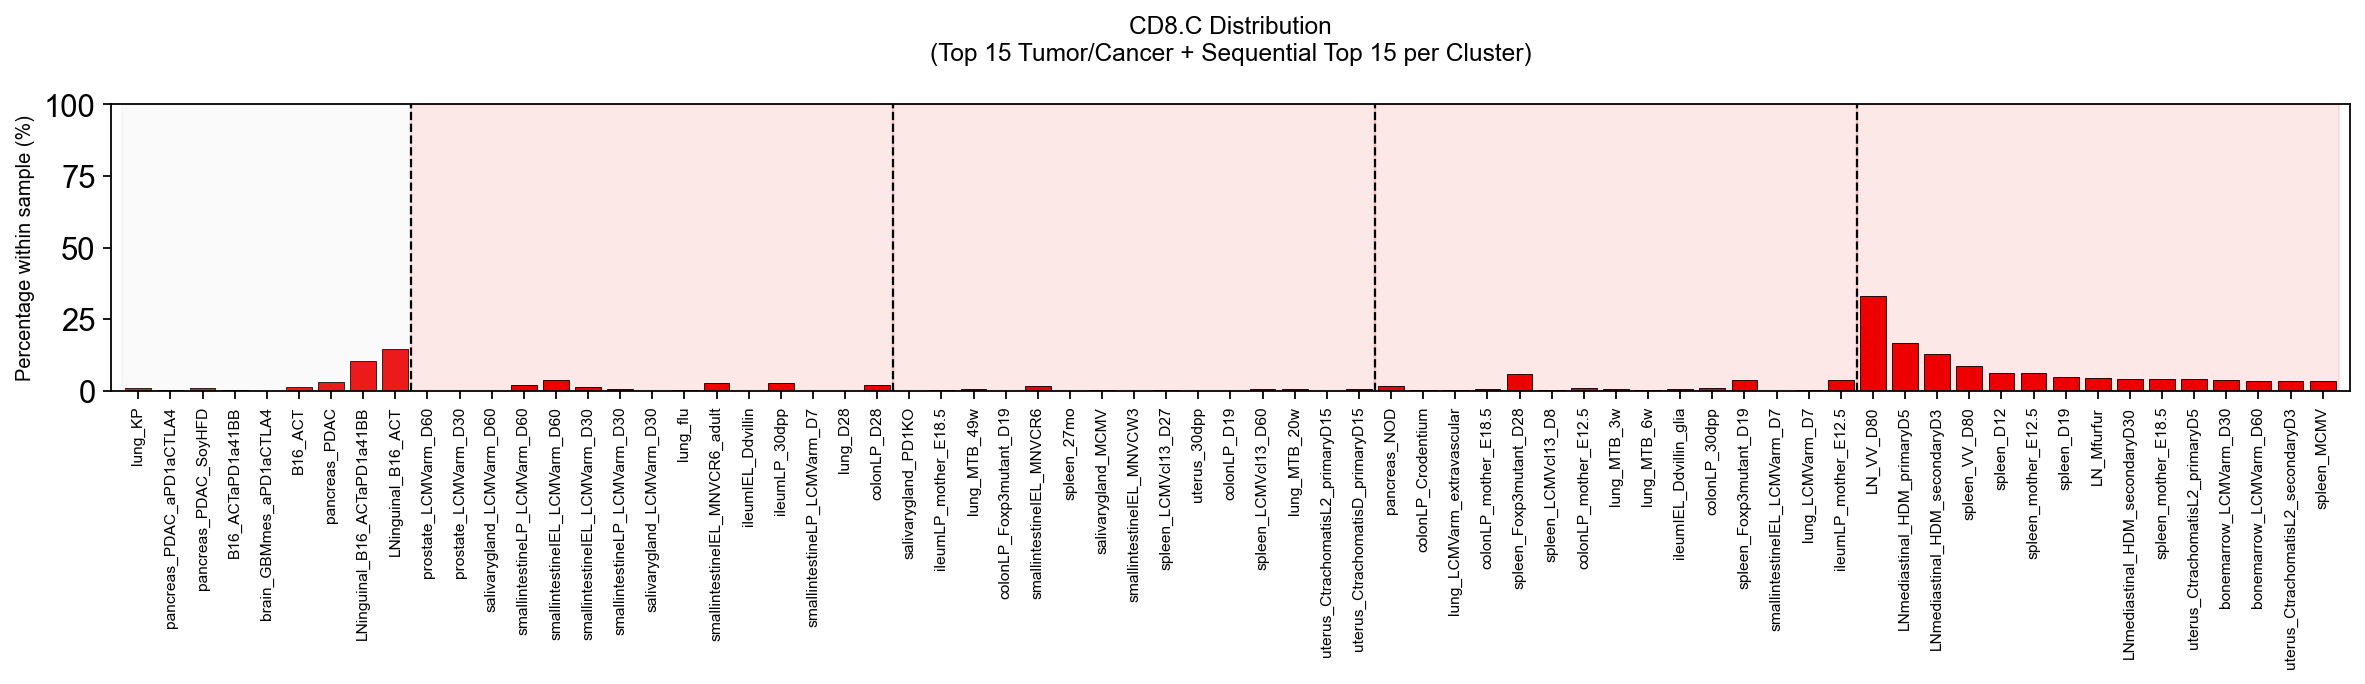

Saved: Fig_6d_CD8.C.pdf
 → Tumor: 9 | Q: 15 | R: 15 | S: 15 | C: 15



In [42]:
# Fig. 6d — Bar plot showing cluster distribution
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================
# Settings
# ==============================================================
clusters = ['CD8.Q', 'CD8.R', 'CD8.S', 'CD8.C']

# Exclusions
exclude_conditions = ['KbDbKO', 'KbDbQa1KO', 'KbDbQa1KO_MCMV', 'thymus']

# Load data
file_path = 'data/immgenT-CD8.xlsx'
df = pd.read_excel(file_path)

# === FILTERS ===
if 'target_cells' in df.columns:
    df = df[~df['target_cells'].str.contains('CD4\+ CD44\+', case=False, na=False)].copy()
    unwanted = ['Treg', 'CD4+ T', 'DN', 'DO11.10 KJ1-26', 'OT2', 'TCRBV-TCRGD', 'TFH',
                'Vd6b F4.22', 'Vg4 49.2', 'Vg6 1C10', 'Vg7 F2.67', 'thymocytes']
    mask = df['target_cells'].isin(unwanted) | df['target_cells'].str.contains('|'.join(unwanted), case=False, na=False)
    df = df[~mask].copy()

df = df[~df['condition_detailed_organ'].str.contains('|'.join(exclude_conditions), case=False, na=False)].copy()

if 'condition_detailed_simplified' in df.columns:
    df = df[df['condition_detailed_simplified'] != 'baseline'].copy()

# Average replicates
agg_dict = {f'{cl}.prop': 'mean' for cl in clusters}
agg_dict.update({f'{cl}.ncells': 'mean' for cl in clusters})
if 'condition_broad' in df.columns:
    agg_dict['condition_broad'] = 'first'

df_agg = df.groupby('condition_detailed_organ', as_index=False).agg(agg_dict)

# Cell count filter
min_cells = 10
valid_mask = df_agg[[f'{cl}.ncells' for cl in clusters]].ge(min_cells).any(axis=1)
df_agg = df_agg[valid_mask].copy()

print(f"Final unique conditions: {df_agg.shape[0]}")

# ==============================================================
# 1. Top 15 Tumor/Cancer
# ==============================================================
if 'condition_broad' in df_agg.columns:
    tumor_mask = df_agg['condition_broad'].str.contains('tumor|cancer', case=False, na=False)
else:
    tumor_mask = df_agg['condition_detailed_organ'].str.contains('tumor|cancer', case=False, na=False)

tumor_df = df_agg[tumor_mask].copy()
tumor_df['total_prop'] = tumor_df[[f'{cl}.prop' for cl in clusters]].sum(axis=1)
top15_tumor = tumor_df.nlargest(15, 'total_prop')['condition_detailed_organ'].tolist()

# ==============================================================
# 2. Sequential Top 15 per cluster (no overlap)
# ==============================================================
remaining = df_agg[~df_agg['condition_detailed_organ'].isin(top15_tumor)].copy()
top15_per_cluster = {}

for cl in clusters:
    if len(remaining) == 0:
        top15_per_cluster[cl] = []
        continue
    top15 = remaining.nlargest(15, f'{cl}.prop')['condition_detailed_organ'].tolist()
    top15_per_cluster[cl] = top15
    # Remove assigned conditions from remaining
    remaining = remaining[~remaining['condition_detailed_organ'].isin(top15)]

# ==============================================================
# Final ordered list
# ==============================================================
ordered_conditions = (
    top15_tumor +
    top15_per_cluster['CD8.Q'] +
    top15_per_cluster['CD8.R'] +
    top15_per_cluster['CD8.S'] +
    top15_per_cluster['CD8.C']
)

# Section boundaries
n_tumor = len(top15_tumor)
n_Q = len(top15_per_cluster['CD8.Q'])
n_R = len(top15_per_cluster['CD8.R'])
n_S = len(top15_per_cluster['CD8.S'])
n_C = len(top15_per_cluster['CD8.C'])

tumor_end = n_tumor - 0.5
Q_start = tumor_end
Q_end   = Q_start + n_Q
R_start = Q_end
R_end   = R_start + n_R
S_start = R_end
S_end   = S_start + n_S
C_start = S_end
C_end   = len(ordered_conditions) - 0.5

# ==============================================================
# PLOTTING
# ==============================================================
for cluster in clusters:
    color = custom_colors.get(cluster, '#808080')
    
    prop_dict = dict(zip(df_agg['condition_detailed_organ'], df_agg[f'{cluster}.prop']))
    percentages = [prop_dict.get(cond, 0) * 100 for cond in ordered_conditions]

    plt.figure(figsize=(15, 4.5))
    plt.bar(range(len(ordered_conditions)), percentages,
            color=color, edgecolor='black', linewidth=0.4)

    # Background shading
    plt.axvspan(-0.5, tumor_end, color="#dedede", alpha=0.12)
    plt.axvspan(Q_start, Q_end, color=color, alpha=0.09)
    plt.axvspan(R_start, R_end, color=color, alpha=0.09)
    plt.axvspan(S_start, S_end, color=color, alpha=0.09)
    plt.axvspan(C_start, C_end, color=color, alpha=0.09)

    # Separators
    plt.axvline(tumor_end, color='black', linewidth=1.0, linestyle='--')
    plt.axvline(Q_end, color='black', linewidth=1.0, linestyle='--')
    plt.axvline(R_end, color='black', linewidth=1.0, linestyle='--')
    plt.axvline(S_end, color='black', linewidth=1.0, linestyle='--')

    plt.ylabel('Percentage within sample (%)', fontsize=9)
    plt.title(f'{cluster} Distribution\n(Top 15 Tumor/Cancer + Sequential Top 15 per Cluster)', 
              fontsize=11, pad=20)
    plt.xticks(range(len(ordered_conditions)), ordered_conditions,
               rotation=90, ha='center', fontsize=7)
    plt.margins(x=0.005)   # Very tight padding (recommended to start with)
    plt.ylim(0, 100)
    plt.grid(False, axis='y', linestyle=':')
    plt.tight_layout()
    plt.grid(False)
    
    plt.savefig(f"Fig_6d_{cluster}.pdf", format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

    print(f"Saved: Fig_6d_{cluster}.pdf")
    print(f" → Tumor: {n_tumor} | Q: {n_Q} | R: {n_R} | S: {n_S} | C: {n_C}\n")


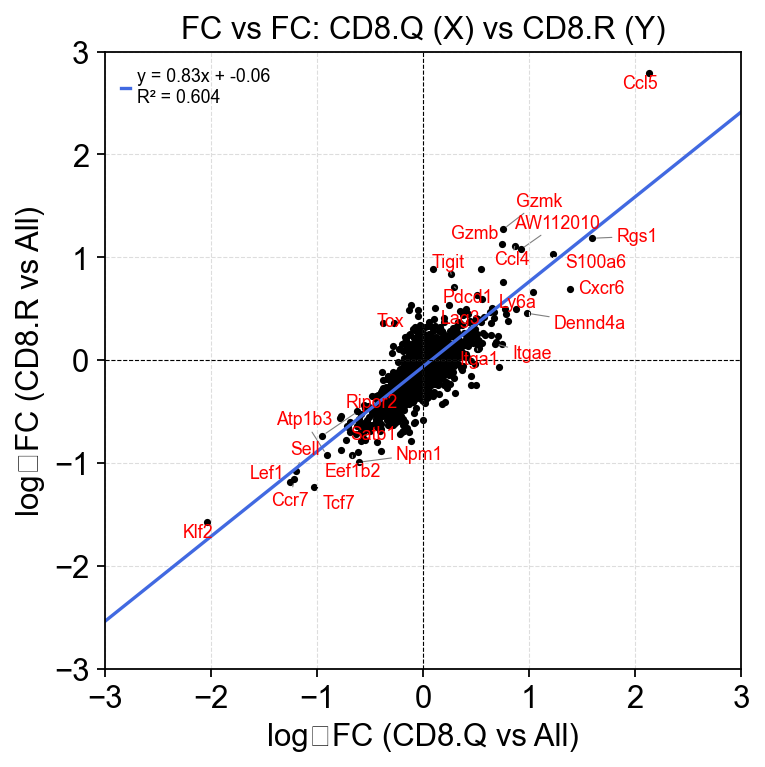


=== CD8.Q vs CD8.R ===
Top 10 positive FC genes:
         SYMBOL  log2FC_CD8.Q_vs_All  log2FC_CD8.R_vs_All     maxFC
2296       Ccl5             2.127281             2.789219  2.789219
12508      Rgs1             1.595435             1.184145  1.595435
3592      Cxcr6             1.384221             0.693946  1.384221
6250       Gzmk             0.756683             1.271330  1.271330
12928    S100a6             1.229609             1.030552  1.229609
6244       Gzmb             0.746084             1.124386  1.124386
2295       Ccl4             0.864706             1.104749  1.104749
1419   AW112010             0.922294             1.075076  1.075076
8364       Ly6a             1.039048             0.662089  1.039048
3915    Dennd4a             0.979412             0.455669  0.979412

Top 10 negative FC genes:
       SYMBOL  log2FC_CD8.Q_vs_All  log2FC_CD8.R_vs_All     minFC
7747     Klf2            -2.037936            -1.573067 -2.037936
8024     Lef1            -1.252565         

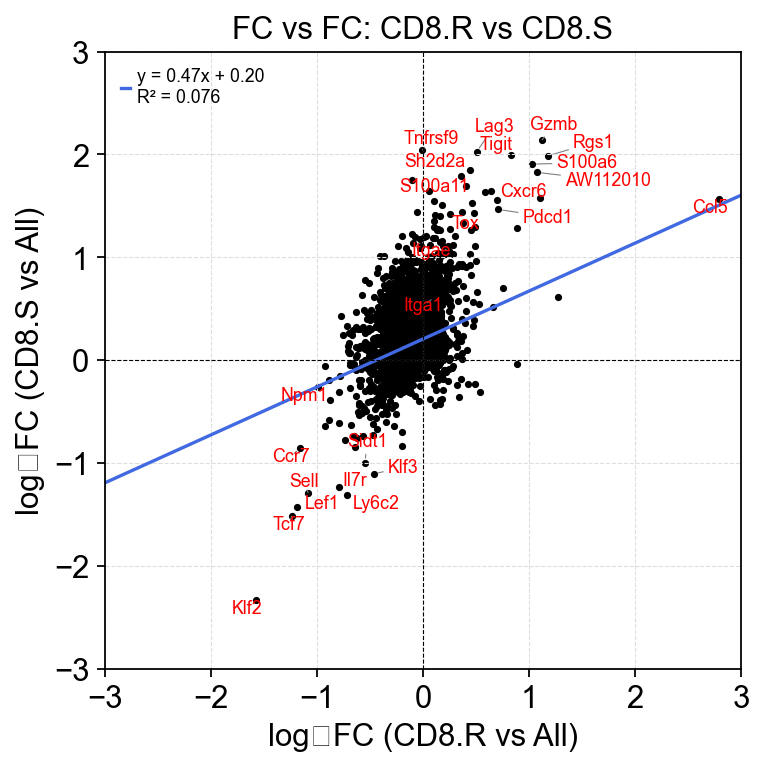


=== CD8.R vs CD8.S ===
Top 10 positive FC genes:
         SYMBOL  log2FC_CD8.R_vs_All  log2FC_CD8.S_vs_All     maxFC
2296       Ccl5             2.789219             1.566684  2.789219
6244       Gzmb             1.124386             2.141935  2.141935
15596   Tnfrsf9            -0.004646             2.043217  2.043217
7931       Lag3             0.506725             2.026168  2.026168
15181     Tigit             0.834833             1.996817  1.996817
12508      Rgs1             1.184145             1.987374  1.987374
12928    S100a6             1.030552             1.904734  1.904734
13382    Sh2d2a             0.439313             1.852162  1.852162
1419   AW112010             1.075076             1.825003  1.825003
12920   S100a11             0.363559             1.792565  1.792565

Top 10 negative FC genes:
      SYMBOL  log2FC_CD8.R_vs_All  log2FC_CD8.S_vs_All     minFC
7747    Klf2            -1.573067            -2.336328 -2.336328
14938   Tcf7            -1.238298            

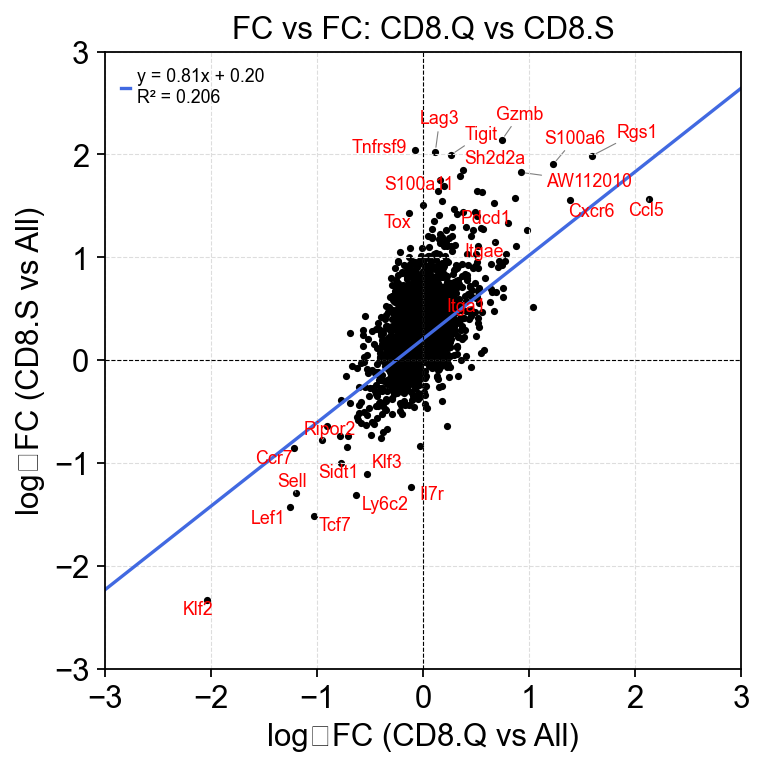


=== CD8.Q vs CD8.S ===
Top 10 positive FC genes:
         SYMBOL  log2FC_CD8.Q_vs_All  log2FC_CD8.S_vs_All     maxFC
6244       Gzmb             0.746084             2.141935  2.141935
2296       Ccl5             2.127281             1.566684  2.127281
15596   Tnfrsf9            -0.077887             2.043217  2.043217
7931       Lag3             0.116845             2.026168  2.026168
15181     Tigit             0.266489             1.996817  1.996817
12508      Rgs1             1.595435             1.987374  1.987374
12928    S100a6             1.229609             1.904734  1.904734
13382    Sh2d2a             0.378836             1.852162  1.852162
1419   AW112010             0.922294             1.825003  1.825003
12920   S100a11             0.345305             1.792565  1.792565

Top 10 negative FC genes:
       SYMBOL  log2FC_CD8.Q_vs_All  log2FC_CD8.S_vs_All     minFC
7747     Klf2            -2.037936            -2.336328 -2.336328
14938    Tcf7            -1.023672         

In [43]:
# Fig. 6e-g — FC versus FC comparisons among exhausted-like clusters
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np
from scipy.stats import linregress

# Load the tab-separated text file
de_data = pd.read_csv("data/ttlist_OneVsAll.txt", sep="\t")

def create_fc_plot(x_col, y_col, x_label, y_label,
                   title, pdf_filename, de_data,
                   xlim=(-3,3), ylim=(-3,3), extra_genes=None):
    if extra_genes is None:
        extra_genes = []

# ------------------------------------------------------------------ #
# 1. Extract cluster identifiers for the p-value columns
# ------------------------------------------------------------------ #
    x_cluster = '_'.join(x_col.split('_')[1:3]) # e.g. CD8.R
    y_cluster = '_'.join(y_col.split('_')[1:3])
# ------------------------------------------------------------------ #
# 2. Pull the data we need
# ------------------------------------------------------------------ #
    cols = ['SYMBOL', x_col, y_col,
            f'adj.P.Val_{x_cluster}_All',
            f'adj.P.Val_{y_cluster}_All']
    df = de_data[cols].copy()
# ------------------------------------------------------------------ #
# 3. Keep only genes that are significant in at least one contrast
# ------------------------------------------------------------------ #
    sig = df[(df[cols[3]] < 0.05) | (df[cols[4]] < 0.05)].copy()
# ------------------------------------------------------------------ #
# 4. Top-10 up / down genes (largest positive & largest negative FC)
# ------------------------------------------------------------------ #
    sig['maxFC'] = sig[[x_col, y_col]].max(axis=1)
    sig['minFC'] = sig[[x_col, y_col]].min(axis=1)
    top_pos = sig.nlargest(10, 'maxFC')
    top_neg = sig.nsmallest(10, 'minFC')
    top_genes = pd.concat([top_pos, top_neg]).drop_duplicates()
# ------------------------------------------------------------------ #
# 5. Regression line (using only the significant points)
# ------------------------------------------------------------------ #
    x = sig[x_col].values
    y = sig[y_col].values
# Remove NaNs that would break the fit
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    slope, intercept, r_val, _, _ = linregress(x_clean, y_clean)
    r2 = r_val**2
# Line coordinates for plotting
    line_x = np.array(xlim)
    line_y = slope * line_x + intercept
# ------------------------------------------------------------------ #
# 6. Plot
# ------------------------------------------------------------------ #
    plt.figure(figsize=(5, 5))
# background dots
    plt.scatter(sig[x_col], sig[y_col],
                c='black', alpha=1, s=5, rasterized=True)
# regression line
    plt.plot(line_x, line_y,
             color='royalblue', lw=1.5,
             label=f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r2:.3f}')
# top-gene labels + extra genes
    texts = []
    # First: top 10 up/down
    for _, row in top_genes.iterrows():
        texts.append(
            plt.text(row[x_col], row[y_col], row['SYMBOL'],
                     fontsize=8, color='red',
                     ha='center', va='center')
        )
    # Second: user-specified extra genes (if present in data)
    extra_df = sig[sig['SYMBOL'].isin(extra_genes)]
    for _, row in extra_df.iterrows():
        texts.append(
            plt.text(row[x_col], row[y_col], row['SYMBOL'],
                     fontsize=8, color='red',
                     ha='center', va='center')
        )

    adjust_text(texts,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
# cosmetics
    plt.xlabel(f'log₂FC ({x_label} vs All)')
    plt.ylabel(f'log₂FC ({y_label} vs All)')
    plt.title(title)
    plt.grid(True, color='#ddd', ls='--', lw=0.5)
    plt.axhline(0, color='k', lw=0.5, ls='--')
    plt.axvline(0, color='k', lw=0.5, ls='--')
    plt.xlim(*xlim)
    plt.ylim(*ylim)
    plt.legend(loc='upper left', fontsize=8, frameon=False)
# ------------------------------------------------------------------ #
# 7. Save & show
# ------------------------------------------------------------------ #
    plt.tight_layout()
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
# ------------------------------------------------------------------ #
# 8. Print top genes (optional)
# ------------------------------------------------------------------ #
    print(f"\n=== {x_label} vs {y_label} ===")
    print("Top 10 positive FC genes:")
    print(top_pos[['SYMBOL', x_col, y_col, 'maxFC']])
    print("\nTop 10 negative FC genes:")
    print(top_neg[['SYMBOL', x_col, y_col, 'minFC']])
    print(f"Regression: slope={slope:.3f}, intercept={intercept:.3f}, R²={r2:.3f}\n")

# ================================================================== #
# Example usage with extra genes
# ================================================================== #
comparisons = [
    # 1. CD8.Q (X) vs CD8.R (Y)
    {
        'x_col': 'log2FC_CD8.Q_vs_All',
        'y_col': 'log2FC_CD8.R_vs_All',
        'x_label': 'CD8.Q',
        'y_label': 'CD8.R',
        'title': 'FC vs FC: CD8.Q (X) vs CD8.R (Y)',
        'pdf_filename': 'Fig_6e-g.pdf',
        'extra_genes': ['Tox', 'Pdcd1', 'Itgae', 'Itga1', 'Tigit', 'Lag3']  # <-- ADD YOUR GENES HERE
    },
    # 2. CD8.R vs CD8.S
    {
        'x_col': 'log2FC_CD8.R_vs_All',
        'y_col': 'log2FC_CD8.S_vs_All',
        'x_label': 'CD8.R',
        'y_label': 'CD8.S',
        'title': 'FC vs FC: CD8.R vs CD8.S',
        'pdf_filename': 'Fig_6e-g_v2.pdf',
        'extra_genes': ['Tox','Pdcd1', 'Itgae', 'Itga1', 'Cxcr6']  # or add genes like ['Tox', 'Eomes']
    },
    # 3. CD8.Q vs CD8.S
    {
        'x_col': 'log2FC_CD8.Q_vs_All',
        'y_col': 'log2FC_CD8.S_vs_All',
        'x_label': 'CD8.Q',
        'y_label': 'CD8.S',
        'title': 'FC vs FC: CD8.Q vs CD8.S',
        'pdf_filename': 'Fig_6e-g_v3.pdf',
        'extra_genes': ['Tox','Pdcd1', 'Itgae', 'Itga1', 'Cxcr6']
    }
]

# Run everything
for comp in comparisons:
    create_fc_plot(
        x_col=comp['x_col'],
        y_col=comp['y_col'],
        x_label=comp['x_label'],
        y_label=comp['y_label'],
        title=comp['title'],
        pdf_filename=comp['pdf_filename'],
        de_data=de_data,
        xlim=(-3, 3),
        ylim=(-3, 3),
        extra_genes=comp.get('extra_genes', [])  # safely pass extra genes
    )


In [44]:
# Fig. 6i - Volcano plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

# === CONFIGURATION ===
cluster = 'CD8.C'
color = '#EE0000'  # Bright red
signature_file = 'data/ttlist_OneVsAll.txt'
save_path = 'Fig_6i.pdf'

# Genes you ALWAYS want labeled in bold red
extra_label_genes = ['Tox', 'Cx3cr1']

# Plot settings
pval_threshold = 0.05
log2fc_threshold = 0.5
label_top_n = 10
figsize = (5, 5)
xlim_min, xlim_max = -4, 4
# =====================

# Load data
df = pd.read_csv(signature_file, sep='\t', encoding='utf-8')

# Extract columns
log2fc_col = f'log2FC_{cluster}_vs_All'
pval_col = f'adj.P.Val_{cluster}_vs_All'
plot_df = df[['SYMBOL', log2fc_col, pval_col]].copy()
plot_df = plot_df.rename(columns={'SYMBOL': 'gene'})
plot_df['log2FC'] = plot_df[log2fc_col]
plot_df['minus_log10_padj'] = -np.log10(plot_df[pval_col].clip(lower=1e-300))

# Significance
plot_df['significant'] = (plot_df[pval_col] < pval_threshold) & (abs(plot_df['log2FC']) > log2fc_threshold)

# Top up/down regulated
sig = plot_df[plot_df['significant']]
top_up = sig[sig['log2FC'] > 0].sort_values('log2FC', ascending=False).head(label_top_n)
top_down = sig[sig['log2FC'] < 0].sort_values('log2FC', ascending=True).head(label_top_n)
top_genes = pd.concat([top_up, top_down])

# Extra genes to label (avoid duplicates with top genes)
extra_df = plot_df[plot_df['gene'].isin(extra_label_genes)]
extra_to_label = extra_df[~extra_df['gene'].isin(top_genes['gene'])]

# === Plot ===
fig, ax = plt.subplots(figsize=figsize)

# Non-significant
ax.scatter(plot_df[~plot_df['significant']]['log2FC'],
           plot_df[~plot_df['significant']]['minus_log10_padj'],
           color='grey', s=1, alpha=0.5, rasterized=True)

# Significant
ax.scatter(plot_df[plot_df['significant']]['log2FC'],
           plot_df[plot_df['significant']]['minus_log10_padj'],
           color=color, s=5, alpha=1, rasterized=True)

# === Labels ===
texts = []

# Top genes
for _, row in top_genes.iterrows():
    texts.append(ax.text(row['log2FC'], row['minus_log10_padj'], row['gene'],
                         fontsize=6, color='black',
                         ha='left' if row['log2FC'] > 0 else 'right'))

# Extra genes (in black)
for _, row in extra_to_label.iterrows():
    texts.append(ax.text(row['log2FC'], row['minus_log10_padj'], row['gene'],
                         fontsize=6, color='black',
                         ha='left' if row['log2FC'] > 0 else 'right'))

# Avoid label overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
            expand_points=(1.3, 1.3), force_text=0.5)

# === Formatting ===
ax.set_xlabel(f'Log2 Fold Change ({cluster} vs Others)')
ax.set_ylabel('-Log10 (Adjusted P-value)')
ax.set_title(f'Volcano Plot: {cluster} vs All Others (Signature Genes)')
ax.set_xlim(xlim_min, xlim_max)

# Threshold lines
ax.axvline(log2fc_threshold, color='black', linestyle='--', lw=0.5)
ax.axvline(-log2fc_threshold, color='black', linestyle='--', lw=0.5)
ax.axhline(-np.log10(pval_threshold), color='black', linestyle='--', lw=0.5)

# **remove the grid**
ax.grid(False)

plt.tight_layout()
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Volcano plot saved: {save_path}")


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


Volcano plot saved: Fig_6i.pdf
